# Dimensionality Reduction for Jet-Flow Snapshots

We use the POD decomposition (already computed in the dataset as Phi, Psi, Sig) as a baseline PCA method. Penalized PCA is then applied directly to the raw fluctuating fields (u,v). This allows a direct comparison between classical PCA/POD, which maximizes variance but yields dense modes, and penalized PCA, which provides localized/smoother structures at the cost of lower explained variance.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from data_utils import load_piv_data, plot_spod_mode
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, MiniBatchSparsePCA, SparsePCA
from numpy.linalg import norm
from time import perf_counter
import os, json
import pandas as pd

In [16]:
file_path = 'data/RUN2_PIV.mat'

data = load_piv_data(file_path)

In [17]:
Sig = data['Sig']
Psi = data['Psi']
Phi = data['Phi']
X_grid = data['X']
Y_grid = data['Y']

⚠️ Note on notation:
- `X_grid`, `Y_grid`: spatial coordinates of the velocity field (used for plotting).
- `X_snap`: snapshot matrix (snapshots × flattened grid) used as input for PCA.


In [4]:
Sig.shape, Psi.shape, Phi.shape

((1, 2030), (2030, 2030), (2030, 171622))

### POD/PCA Results (Phi, Psi, Sig)

- **Sig**: singular values (square roots of covariance eigenvalues).  
  Squared values give the variance (energy) explained by each mode.  

- **Phi**: spatial modes (principal directions in feature space).  
  Each mode can be reshaped into `(Ny, Nx)` fields for `u` and `v`, showing coherent flow structures.  

- **Psi**: temporal coefficients (scores).  
  Each column is the time evolution of one mode, showing how active it is across snapshots.  

The POD/PCA decomposition can be written as:

$$
X \approx \Psi \, \Sigma \, \Phi^T
$$

where:  
- $X$ = snapshot matrix (snapshots × features),  
- $\Psi$ = temporal coefficients,  
- $\Sigma$ = diagonal matrix of singular values (`Sig`),  
- $\Phi$ = spatial modes.


### 1) Explained variance

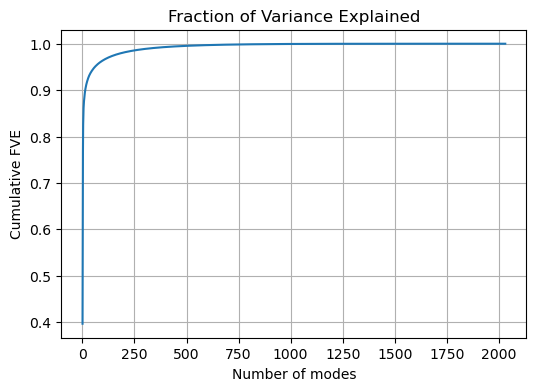

FVE with 10 modes: 0.8857864237205922


In [5]:
eigvals = Sig**2
evr = eigvals / eigvals.sum()            # variance ratio per mode
cum_fve = np.cumsum(evr)

# Flatten to 1D for plotting
evr_1d = evr.ravel()
cum_fve_1d = cum_fve.ravel()

plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(evr_1d)+1), cum_fve_1d)
plt.xlabel("Number of modes")
plt.ylabel("Cumulative FVE")
plt.grid(True)
plt.title("Fraction of Variance Explained")
plt.show()

print("FVE with 10 modes:", cum_fve_1d[9])

### 2) Plot first spatial mode (m=0) as |u| magnitude

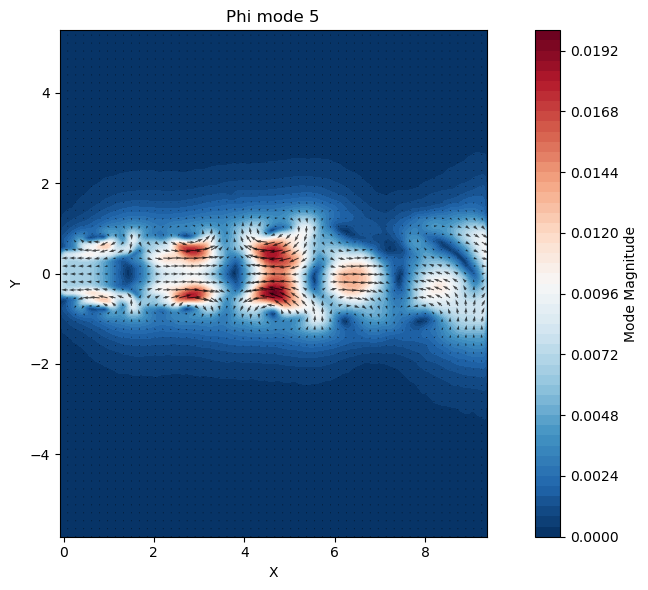

In [ ]:
m = 5
mode = Phi[m]
nx, ny = X_grid.shape
mode_reshaped = mode.reshape(2, nx, ny)

plot_spod_mode(X_grid, Y_grid, mode_reshaped,
               title=f"PCA mode {m}",
               scale=0.5, quiver_step=5)

### 3) Plot temporal coefficient time series

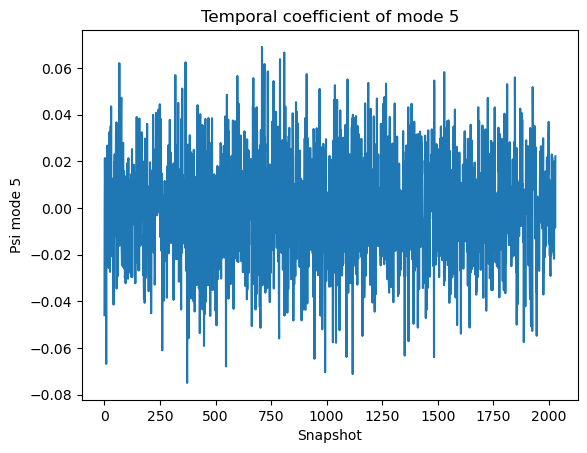

In [13]:
m = 5
plt.plot(Psi[:, m])
plt.xlabel("Snapshot")
plt.ylabel(f"Psi mode {m}")
plt.title(f"Temporal coefficient of mode {m}")
plt.show()

### Why go beyond normal PCA?

Normal PCA (or POD) provides modes that optimally capture the variance/energy of the flow, and these modes already reveal important coherent structures.  
However, PCA modes are typically **global**: almost all spatial points contribute, which can make them hard to interpret physically.  

**Penalized PCA** introduces regularization to overcome this:
- **Sparsity penalties** (Sparse PCA) force many coefficients to zero, producing modes that are more **localized** in space.

This trade-off gives up a small amount of explained variance in exchange for **greater interpretability** and **clearer structures**, which can be especially useful for identifying physically meaningful flow features.


# Penalized PCA for Jet-Flow Snapshots


**Sparse PCA (SPCA) [Zou et al. 2006]**  
  The objective is to obtain modes with many exact zeros, so that each component depends only on a subset of variables.  
  This is achieved by adding an **L1 penalty** (lasso‐style) to the PCA optimization.  
  The advantage is interpretability: it highlights localized structures and makes it easier to say *“this mode only lives in these regions.”*  
  The drawback is that explained variance (FVE) is usually lower than with standard PCA.

### Load & arrange data
- `X` must be **centered** (mean-subtracted).
- Set `(Ny, Nx)` and feature stacking order (here we assume `[u(:), v(:)]`).


In [14]:
file_path = 'compressed_data/RUN2_PIV_compressed.npz'

# Load the data from the .npz file
try:
    data = np.load(file_path)
    print("File loaded successfully!")
    # data['array_name']
    # To see what arrays are in the file, we use data.files
    print("Arrays in the .npz file:", data.files)

except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

File loaded successfully!
Arrays in the .npz file: ['X', 'Y', 'u', 'v']


In [15]:
X_grid = data['X']
Y_grid = data['Y']
u = data['u']
v = data['v']

n, Ny, Nx = u.shape
nx, ny = X_grid.shape
# --- Build snapshot matrix X = [u(:), v(:)] ---
X_snap = np.concatenate([
    u.reshape(n, Ny*Nx),
    v.reshape(n, Ny*Nx)
], axis=1).astype(np.float32)

**Centering** ensures PCA captures variance around the mean.

In [16]:
X_snap -= X_snap.mean(axis=0, keepdims=True)
print("X shape:", X_snap.shape)   # (2031, 2*269*319) = (2031, 171622)

X shape: (2030, 171622)


### Dimensionality reduction before Sparse PCA

Running Sparse PCA directly on the full snapshot matrix is computationally infeasible due to the very high number of features ($d \sim 170{,}000$).  
To address this, we first reduce dimensionality with randomized PCA, keeping the first $r$ components that capture most of the variance (typically >90%).  
Sparse PCA is then applied in this reduced space, and the resulting components are back-projected to the original variables.  

This procedure may discard a small fraction of low-energy variance, but it ensures tractability while preserving the main flow structures and enables a fair comparison with standard PCA/POD.


### ⚠️ In this pipeline I first reduce the data with PCA and then apply SPCA in the PCA space without whitening. This is incorrect because the L1 penalty just selects dominant PCs, so the resulting modes look almost identical to standard PCA and sparsity is misleading. Go to [Issue with SPCA results](#issue-with-spca-results) to see the corrected code.

FVE with 50 comps: 0.944
FVE with 100 comps: 0.964
FVE with 200 comps: 0.981
FVE with 300 comps: 0.989


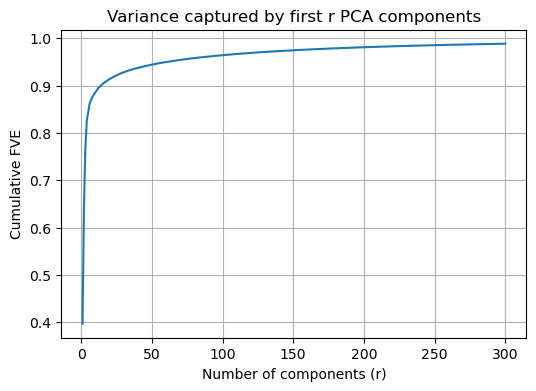

In [ ]:
# X: (n, d) snapshot matrix (already centered, float32 recommended)
r = 300

pca_check = PCA(n_components=r, svd_solver='randomized', random_state=0)
pca_check.fit(X_snap)

evr = pca_check.explained_variance_ratio_      # variance ratio per component
cum_fve = np.cumsum(evr)                       # cumulative variance explained

# Print how much variance is captured
for k in [50, 100, 200, 300]:
    if k <= len(cum_fve):
        print(f"FVE with {k} comps: {cum_fve[k-1]:.3f}")

# Plot the cumulative curve
plt.figure(figsize=(6,4))
plt.plot(np.arange(1, len(cum_fve)+1), cum_fve)
plt.xlabel("Number of components (r)")
plt.ylabel("Cumulative FVE")
plt.title("Variance captured by first r PCA components")
plt.grid(True)
plt.show()

From the FVE analysis we observe that:
- 50 components capture ~94% of the variance,
- 100 components capture ~96%,
- 200 components capture ~98%,
- 300 components capture ~99%.

This shows that most of the flow variance is concentrated in a relatively small number of directions.  
Therefore, applying Sparse PCA in a reduced space of 100–200 components is sufficient to preserve the main flow structures while making the computation tractable.

In [7]:
def spca_fit_eval(X_snap, r=200, k=10, alpha=0.5, batch_size=256, max_iter=200, random_state=0, repeats=1):
    """
    Returns: dict with fve, sparsity_W, time, stability (scores corr across repeats)
    Runs SPCA `repeats` times to get a simple stability score (median corr of scores).
    """
    X = X_snap.astype(np.float32, copy=False)
    n, d = X.shape

    # 1) PCA reduce
    t0 = time.time()
    pca = PCA(n_components=r, svd_solver='randomized', random_state=random_state)
    Z   = pca.fit_transform(X)      # (n, r)
    V_r = pca.components_           # (r, d)
    t_pca = time.time() - t0

    # 2) Repeat SPCA for stability
    scores_list = []
    W_list = []

    for rep in range(repeats):
        mb = MiniBatchSparsePCA(
            n_components=k,
            alpha=alpha,
            batch_size=batch_size,
            max_iter=max_iter,
            n_jobs=-1,
            random_state=random_state + rep
        )
        W = mb.fit(Z).components_     # (k, r)
        S = Z @ W.T                   # (n, k)
        scores_list.append(S)
        W_list.append(W)

    # Back-project from the *first* fit to compute FVE
    W0 = W_list[0]
    modes0 = W0 @ V_r
    mnorm = np.linalg.norm(modes0, axis=1, keepdims=True) + 1e-12
    modes0 = modes0 / mnorm
    scores0 = scores_list[0] * mnorm.ravel()

    Xhat = scores0 @ modes0
    total_var = np.sum(np.var(X, axis=0, ddof=1))
    recon_err = np.sum((X - Xhat)**2) / (n - 1)
    fve = float(1.0 - recon_err / total_var)

    # Sparsity measured on W (reduced space)
    sparsity_W = float(np.mean(np.isclose(W0, 0.0)))

    # Stability: median correlation across repeats (pairwise corr of scores)
    stability = None
    if repeats >= 2:
        cors = []
        for i in range(repeats-1):
            S1 = scores_list[i]
            S2 = scores_list[i+1]
            # mode-wise correlation, allowing sign flip
            for m in range(k):
                a, b = S1[:, m], S2[:, m]
                c = np.corrcoef(a, b)[0,1]
                cors.append(abs(c))
        stability = float(np.median(cors)) if cors else None

    return dict(
        fve=fve,
        sparsity_W=sparsity_W,
        stability=stability,
        time=float(time.time() - t0)
    )

### Hyperparameters of Sparse PCA

Sparse PCA introduces hyperparameters that control the balance between explained variance and sparsity:

- **n_components**: Number of components to extract.  
  - Too few → risk of losing important flow structures.  
  - Too many → noise and redundancy.  
  - We choose based on FVE (fraction of variance explained).

- **alpha (ℓ1 penalty)**: Controls sparsity of loadings (how many spatial points are active in each mode).  
  - Small $\alpha$ → loadings look like normal PCA (dense).  
  - Large $\alpha$ → many coefficients shrink to zero (localized modes).

- **ridge_alpha (ℓ2 penalty)**: Adds stability by shrinking coefficients smoothly.  
  - Useful when variables are highly correlated (as in flow fields).  
  - Acts as a regularizer to avoid overfitting.

- **max_iter / tol**: Convergence parameters for the optimization.  
  - Important for large datasets; set higher if results don’t converge.

In summary:  
- *n_components* defines how many patterns we want.  
- *alpha* is the main knob to trade variance for spatial localization.  
- *ridge_alpha* provides stability.  
Hyperparameter selection usually involves scanning a grid of values and comparing reconstruction error, explained variance, and interpretability of the resulting modes.


### Hyperparameter selection

In [12]:
k_list = [8, 12, 14, 16]
alpha_list = [0.1, 0.2, 0.4]

results = []
for k in k_list:
    for alpha in alpha_list:
        out = spca_fit_eval(X_snap, r=200, k=k, alpha=alpha, repeats=2)
        results.append((k, alpha, out["fve"], out["sparsity_W"], out["stability"], out["time"]))
        print(f"k={k:<2} alpha={alpha:<3} | FVE={out['fve']:.3f}  sparsity={out['sparsity_W']:.1%}  "
              f"stab={out['stability'] if out['stability'] is not None else np.nan:.3f}  "
              f"time={out['time']:.1f}s")

k=8  alpha=0.1 | FVE=0.876  sparsity=99.5%  stab=1.000  time=59.5s
k=8  alpha=0.2 | FVE=0.876  sparsity=99.5%  stab=1.000  time=63.8s
k=8  alpha=0.4 | FVE=0.876  sparsity=99.5%  stab=1.000  time=58.5s
k=12 alpha=0.1 | FVE=0.894  sparsity=99.5%  stab=1.000  time=59.0s
k=12 alpha=0.2 | FVE=0.894  sparsity=99.5%  stab=1.000  time=61.2s
k=12 alpha=0.4 | FVE=0.894  sparsity=99.5%  stab=1.000  time=56.8s
k=14 alpha=0.1 | FVE=0.900  sparsity=99.5%  stab=1.000  time=75.4s
k=14 alpha=0.2 | FVE=0.900  sparsity=99.5%  stab=1.000  time=71.7s
k=14 alpha=0.4 | FVE=0.900  sparsity=99.5%  stab=1.000  time=67.9s
k=16 alpha=0.1 | FVE=0.906  sparsity=99.5%  stab=1.000  time=73.2s
k=16 alpha=0.2 | FVE=0.906  sparsity=99.5%  stab=1.000  time=67.8s
k=16 alpha=0.4 | FVE=0.906  sparsity=99.5%  stab=1.000  time=60.6s


The grid search revealed that with r=200, SPCA converged to extremely sparse solutions (≈99.5% zeros) for all tested α values, with perfect stability. This indicates that the model is over-regularized and most spatial information is lost. To obtain more interpretable yet informative modes, the next step is to explore smaller values of α (e.g. 0.05 or 0.01) and/or increase the PCA pre-reduction rank r, aiming for a balance where sparsity remains high (60–95%) but FVE is not drastically lower than that of standard PCA.

In [14]:
r = 300
k_list = [8, 12, 14, 16]
alpha_list = [0.01, 0.1, 0.2]

results = []
for k in k_list:
    for alpha in alpha_list:
        out = spca_fit_eval(X_snap, r=r, k=k, alpha=alpha, repeats=2)
        results.append((k, alpha, out["fve"], out["sparsity_W"], out["stability"], out["time"]))
        print(f"k={k:<2} alpha={alpha:<3} | FVE={out['fve']:.3f}  sparsity={out['sparsity_W']:.1%}  "
              f"stab={out['stability'] if out['stability'] is not None else np.nan:.3f}  "
              f"time={out['time']:.1f}s")

k=8  alpha=0.01 | FVE=0.872  sparsity=99.4%  stab=1.000  time=70.8s
k=8  alpha=0.1 | FVE=0.870  sparsity=99.7%  stab=1.000  time=61.0s
k=8  alpha=0.2 | FVE=0.870  sparsity=99.7%  stab=1.000  time=62.0s
k=12 alpha=0.01 | FVE=0.892  sparsity=99.2%  stab=1.000  time=57.2s
k=12 alpha=0.1 | FVE=0.882  sparsity=99.7%  stab=1.000  time=52.8s
k=12 alpha=0.2 | FVE=0.882  sparsity=99.7%  stab=1.000  time=66.7s
k=14 alpha=0.01 | FVE=0.884  sparsity=99.3%  stab=1.000  time=67.2s
k=14 alpha=0.1 | FVE=0.883  sparsity=99.7%  stab=1.000  time=55.5s
k=14 alpha=0.2 | FVE=0.883  sparsity=99.7%  stab=1.000  time=58.6s
k=16 alpha=0.01 | FVE=0.905  sparsity=99.0%  stab=1.000  time=60.0s
k=16 alpha=0.1 | FVE=0.899  sparsity=99.7%  stab=1.000  time=56.9s
k=16 alpha=0.2 | FVE=0.899  sparsity=99.7%  stab=1.000  time=51.4s


In [15]:
r = 200

k_list = [8, 12, 14, 16]
alpha_list = [0.01, 0.02, 0.05]

results = []
for k in k_list:
    for alpha in alpha_list:
        out = spca_fit_eval(X_snap, r=r, k=k, alpha=alpha, repeats=2)
        results.append((k, alpha, out["fve"], out["sparsity_W"], out["stability"], out["time"]))
        print(f"k={k:<2} alpha={alpha:<3} | FVE={out['fve']:.3f}  sparsity={out['sparsity_W']:.1%}  "
              f"stab={out['stability'] if out['stability'] is not None else np.nan:.3f}  "
              f"time={out['time']:.1f}s")

k=8  alpha=0.01 | FVE=0.876  sparsity=99.5%  stab=1.000  time=68.6s
k=8  alpha=0.02 | FVE=0.876  sparsity=99.5%  stab=1.000  time=62.2s
k=8  alpha=0.05 | FVE=0.876  sparsity=99.5%  stab=1.000  time=52.5s
k=12 alpha=0.01 | FVE=0.894  sparsity=99.5%  stab=1.000  time=54.1s
k=12 alpha=0.02 | FVE=0.894  sparsity=99.5%  stab=1.000  time=52.9s
k=12 alpha=0.05 | FVE=0.894  sparsity=99.5%  stab=1.000  time=52.6s
k=14 alpha=0.01 | FVE=0.900  sparsity=99.0%  stab=1.000  time=62.1s
k=14 alpha=0.02 | FVE=0.900  sparsity=99.2%  stab=1.000  time=63.0s
k=14 alpha=0.05 | FVE=0.900  sparsity=99.4%  stab=1.000  time=64.3s
k=16 alpha=0.01 | FVE=0.906  sparsity=98.7%  stab=1.000  time=68.1s
k=16 alpha=0.02 | FVE=0.906  sparsity=99.2%  stab=1.000  time=69.1s
k=16 alpha=0.05 | FVE=0.906  sparsity=99.5%  stab=1.000  time=68.8s


In [16]:
k_list = [12]
alpha_list = [0.001, 0.002, 0.01]

results = []
for k in k_list:
    for alpha in alpha_list:
        out = spca_fit_eval(X_snap, r=r, k=k, alpha=alpha, repeats=2)
        results.append((k, alpha, out["fve"], out["sparsity_W"], out["stability"], out["time"]))
        print(f"k={k:<2} alpha={alpha:<3} | FVE={out['fve']:.3f}  sparsity={out['sparsity_W']:.1%}  "
              f"stab={out['stability'] if out['stability'] is not None else np.nan:.3f}  "
              f"time={out['time']:.1f}s")

k=12 alpha=0.001 | FVE=0.894  sparsity=98.6%  stab=1.000  time=58.7s
k=12 alpha=0.002 | FVE=0.894  sparsity=99.1%  stab=1.000  time=56.2s
k=12 alpha=0.01 | FVE=0.894  sparsity=99.5%  stab=1.000  time=66.5s


### SPCA computation

In [19]:
def spca_save(
    X_snap: np.ndarray,           # (n, d) CENTERED snapshot matrix; float32 recommended
    Ny: int, Nx: int,             # grid size; d must be 2*Ny*Nx for [u(:), v(:)]
    out_dir: str,                 # folder to write files
    dataset_name: str,            # used in filenames, e.g. "RUN01"
    r: int,                       # PCA pre-reduction rank (e.g. 200)
    k: int,                       # number of sparse components (e.g. 10–15)
    alpha: float,                 # sparsity strength (smaller = denser)
    batch_size: int = 256,
    max_iter: int = 200,
    random_state: int = 0,
    skip_if_exists: bool = True,  # skip if outputs already exist
) -> None:
    """
    Two-stage SPCA (PCA -> MiniBatchSparsePCA) with file outputs.
    Writes:
      - {dataset_name}_spca.npz   (arrays: 'modes' [k,d], 'scores' [n,k])
      - {dataset_name}_spca.json  (metadata: r,k,alpha,FVE,shapes,paths)
    Returns nothing.
    """
    os.makedirs(out_dir, exist_ok=True)
    npz_path  = os.path.join(out_dir, f"{dataset_name}_spca.npz")
    meta_path = os.path.join(out_dir, f"{dataset_name}_spca.json")

    if skip_if_exists and os.path.exists(npz_path) and os.path.exists(meta_path):
        print(f"[SPCA] Skipping {dataset_name} (outputs already exist).")
        return

    X = X_snap.astype(np.float32, copy=False)
    n, d = X.shape
    assert d == 2*Ny*Nx, f"d={d} must equal 2*Ny*Nx={2*Ny*Nx} (stacking [u(:), v(:)])"

    # 1) PCA pre-reduction to r
    pca = PCA(n_components=r, svd_solver='randomized', random_state=random_state)
    Z   = pca.fit_transform(X)      # (n, r)
    V_r = pca.components_           # (r, d)

    # 2) Sparse PCA in reduced space
    mb = MiniBatchSparsePCA(
        n_components=k,
        alpha=alpha,
        batch_size=batch_size,
        max_iter=max_iter,
        n_jobs=-1,
        random_state=random_state
    )
    W = mb.fit(Z).components_       # (k, r)

    # Back-project to original variables
    scores = Z @ W.T                # (n, k)
    modes  = W @ V_r                # (k, d)

    # Normalize modes (||mode||2=1) and rescale scores
    mnorm = np.linalg.norm(modes, axis=1, keepdims=True) + 1e-12
    modes  = modes / mnorm
    scores = scores * mnorm.ravel()

    # Reconstruction FVE
    Xhat = scores @ modes
    total_var = np.sum(np.var(X, axis=0, ddof=1))
    recon_err = np.sum((X - Xhat)**2) / (n - 1)
    fve = float(1.0 - recon_err / total_var)

    # Save arrays
    np.savez(npz_path,
             modes=modes.astype(np.float32, copy=False),
             scores=scores.astype(np.float32, copy=False))

    # Save metadata
    with open(meta_path, "w") as f:
        json.dump({
            "dataset_name": dataset_name,
            "Ny": Ny, "Nx": Nx, "n": n, "d": d,
            "r": r, "k": k, "alpha": alpha,
            "batch_size": batch_size, "max_iter": max_iter,
            "random_state": random_state,
            "fve_reconstruction": fve,
            "files": {"npz": npz_path}
        }, f, indent=2)

    print(f"[SPCA] Saved {dataset_name}: FVE={fve:.3f}  -> {npz_path}")


In [ ]:
best_r, best_k, best_alpha = 200, 12, 0.001

spca_save(X_snap, Ny=Ny, Nx=Nx,
          out_dir="./SPCA_data", dataset_name="RUN2",
          r=best_r, k=best_k, alpha=best_alpha, skip_if_exists=True)

[SPCA] Saved RUN2: FVE=0.894  -> ./SPCA_data\RUN2_spca.npz


In [2]:
data = np.load("./SPCA_data/RUN2_spca.npz")
grid = np.load("./spatial_grid.npz")
modes, scores = data["modes"], data["scores"]
X_grid, Y_grid = grid["X_grid"], grid["Y_grid"]

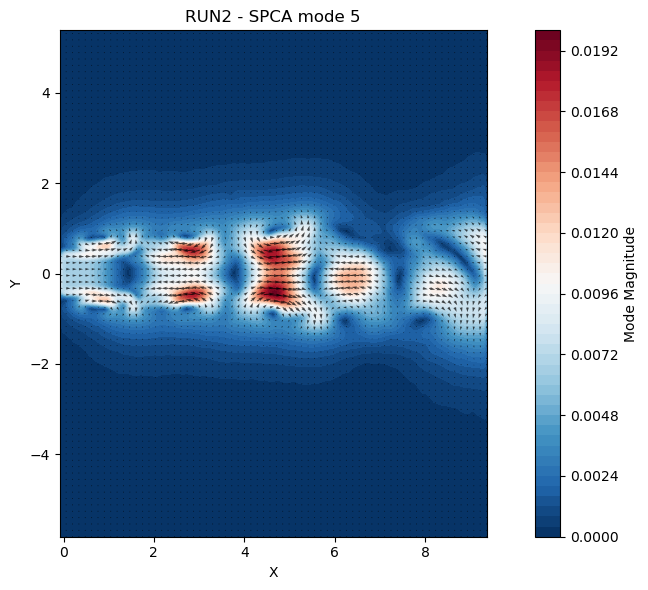

In [12]:
m = 5
nx, ny = X_grid.shape
mode_reshaped = modes[m].reshape(2, nx, ny)

plot_spod_mode(X_grid, Y_grid, mode_reshaped,
               title=f"RUN2 - SPCA mode {m}",
               scale=0.7, quiver_step=4)

### Issue with SPCA results

In my first attempts with SPCA I was running into a bunch of issues. Basically, the way I had set up the code made SPCA end up looking almost identical to normal PCA. The problem was that I was applying the L1 penalty in PCA space without whitening the data, so the algorithm just picked a couple of dominant PCs, and when I projected them back the modes looked the same as before. On top of that, I was calculating sparsity on the reduced weights instead of on the actual modes in the original grid, so the numbers I got (like ~99% zeros) were misleading and not really telling me anything useful. To fix all of this, I simplified the pipeline: I now standardize the features so the L1 penalty is fair, compute sparsity directly on the modes in the physical space, use a quantile-based mask to ignore inactive points, and fit everything with MiniBatchSparsePCA so it runs much faster. With these changes the modes are actually different from PCA and much easier to interpret.


In [32]:
def _quantile_mask_by_feature_std(X, keep_q=0.30):
    # per-feature std; keep top-q fraction
    s = X.std(axis=0, ddof=1)
    t = np.quantile(s, 1.0 - keep_q)
    return s >= t

def _sparsity_on_modes(components_full, rel_thr=1e-3):
    # components_full: (k, d) in ORIGINAL variable space
    k, d = components_full.shape
    mmax = np.maximum(np.abs(components_full).max(axis=1, keepdims=True), 1e-12)
    mask_small = np.abs(components_full) < (rel_thr * mmax)
    return mask_small.mean()  # fraction of near-zeros across all modes

def _fve_chunked(X_std_masked, codes, comps_masked, batch=512):
    # FVE = 1 - ||X - S U||_F^2 / ||X||_F^2, computed in batches to avoid big memory
    n = X_std_masked.shape[0]
    denom = norm(X_std_masked, 'fro')**2
    err2 = 0.0
    for i0 in range(0, n, batch):
        i1 = min(i0 + batch, n)
        # reconstruct batch
        R = codes[i0:i1] @ comps_masked       # (b, k) @ (k, p) -> (b, p)
        E = X_std_masked[i0:i1] - R
        err2 += norm(E, 'fro')**2
    return max(0.0, 1.0 - err2 / max(denom, 1e-12))

def spca_pipeline(
    X,                      # shape (n_samples, n_features), use float32 if possible
    n_components=10,
    alpha=0.05,             # higher -> more sparse
    ridge_alpha=1e-6,       # shrinks coefficients smoothly, improves conditioning & stability, can reduce overfitting/noise; too large will reduce sparsity
    keep_q=0.30,            # keep top 30% most-variant features
    use_minibatch=True,     # True -> MiniBatchSparsePCA, False -> SparsePCA
    max_iter=400,
    batch_size=None,        # None -> auto for MiniBatch
    compute_fve=False,
    random_state=0
):
    t0 = perf_counter()
    X = np.asarray(X, dtype=np.float32, order='C')
    n, d = X.shape

    # 1) Feature mask (variance quantile)
    feat_mask = _quantile_mask_by_feature_std(X, keep_q=keep_q)
    X_masked = X[:, feat_mask]

    # 2) Standardize (very important for L1 fairness)
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xs = scaler.fit_transform(X_masked)

    # 3) Fit SPCA
    if use_minibatch:
        if batch_size is None:
            batch_size = min(2048, max(128, n // 20))
        model = MiniBatchSparsePCA(
            n_components=n_components,
            alpha=alpha,
            ridge_alpha=ridge_alpha,
            batch_size=batch_size,
            n_jobs=-1,
            max_iter=max_iter,
            random_state=random_state
        )
    else:
        model = SparsePCA(
            n_components=n_components,
            alpha=alpha,
            ridge_alpha=ridge_alpha,
            max_iter=max_iter,
            n_jobs=-1,
            random_state=random_state
        )

    model.fit(Xs)
    comps_masked = model.components_.astype(np.float32)        # (k, p_kept)
    codes = model.transform(Xs).astype(np.float32)             # (n, k)

    # 4) Put modes back in ORIGINAL variable space (fill zeros outside mask)
    k = comps_masked.shape[0]
    components_full = np.zeros((k, d), dtype=np.float32)
    components_full[:, feat_mask] = comps_masked

    # 5) Report sparsity on modes (original space)
    sparsity_modes = _sparsity_on_modes(components_full, rel_thr=1e-3)

    # 6) Optional FVE (chunked to save RAM)
    fve = None
    if compute_fve:
        fve = _fve_chunked(Xs, codes, comps_masked, batch=512)

    out = {
        "components": components_full,   # (k, d) sparse modes in original space
        "codes": codes,                  # (n, k)
        "feature_mask": feat_mask,       # boolean mask used
        "sparsity_modes": float(sparsity_modes),
        "fve": None if fve is None else float(fve),
        "time_sec": perf_counter() - t0,
        "model": model,
        "scaler": scaler
    }
    return out


In [ ]:
# X: snapshots × features (e.g., samples × (u||v) flattened)
res = spca_pipeline(X_snap, n_components=10, alpha=0.05, keep_q=0.30, use_minibatch=True, compute_fve=False)

print(f"Sparsity on modes (orig space): {res['sparsity_modes']:.3f}")
print(f"Time: {res['time_sec']:.1f}s  |  kept features: {res['feature_mask'].sum()} / {X_snap.shape[1]}")

SPCA_MODES = res["components"]      # shape (k, d)

Sparsity on modes (orig space): 0.703
Time: 40.4s  |  kept features: 51487 / 171622


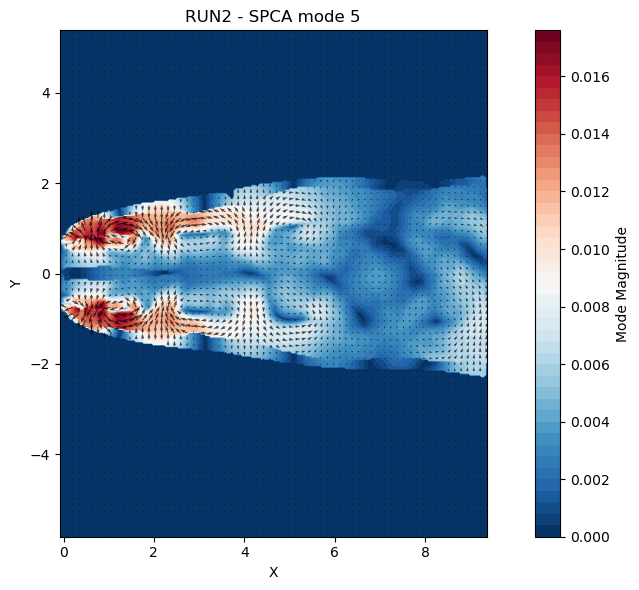

In [16]:
m = 5

plot_spod_mode(X_grid, Y_grid, SPCA_MODES[m].reshape(2, nx, ny),
               title=f"RUN2 - SPCA mode {m}",
                scale=0.6, quiver_step=4)

### Hyperparameter selection

 alpha  n_components  keep_q  kept_features  total_features  sparsity_modes      FVE  time_sec
  0.02            12    0.35          60068          171622        0.652456 0.727907 51.577801
  0.05            12    0.35          60068          171622        0.654152 0.727901 49.673046
  0.10            12    0.35          60068          171622        0.657239 0.727880 46.697604
  0.20            12    0.35          60068          171622        0.663141 0.727796 45.653189
  0.40            12    0.35          60068          171622        0.676889 0.727470 45.243118
  0.70            12    0.35          60068          171622        0.704803 0.726580 43.767701
  1.00            12    0.35          60068          171622        0.730412 0.725281 42.229451


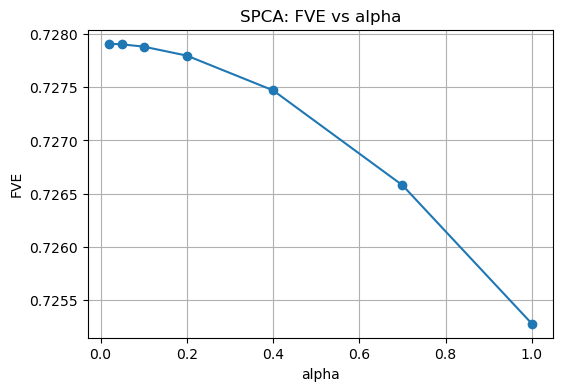

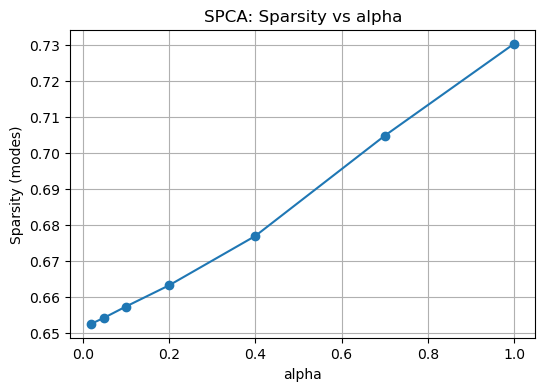

In [33]:
# --- grid to test ---
alphas = [0.02, 0.05, 0.10, 0.20, 0.4, 0.7, 1.0]
n_components = 12
keep_q = 0.35
use_minibatch = True

rows = []
for a in alphas:
    res = spca_pipeline(
        X_snap,
        n_components=n_components,
        alpha=a,
        keep_q=keep_q,
        use_minibatch=use_minibatch,
        compute_fve=True,
        random_state=0
    )
    rows.append({
        "alpha": a,
        "n_components": n_components,
        "keep_q": keep_q,
        "kept_features": int(res["feature_mask"].sum()),
        "total_features": X_snap.shape[1],
        "sparsity_modes": res["sparsity_modes"],
        "FVE": res["fve"],
        "time_sec": res["time_sec"]
    })

sweep_df = pd.DataFrame(rows).sort_values("alpha").reset_index(drop=True)
print(sweep_df.to_string(index=False))


# --- quick visuals ---
plt.figure(figsize=(6,4))
plt.plot(sweep_df["alpha"], sweep_df["FVE"], marker="o")
plt.xlabel("alpha"); plt.ylabel("FVE"); plt.title("SPCA: FVE vs alpha"); plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(sweep_df["alpha"], sweep_df["sparsity_modes"], marker="o")
plt.xlabel("alpha"); plt.ylabel("Sparsity (modes)"); plt.title("SPCA: Sparsity vs alpha"); plt.grid(True)
plt.show()


We lose less than 0.003 FVE for a 0.08 increase in sparsity.

In [35]:
# --- grid to test ---
alpha = 1.0
ridge_alphas = [1e-4, 1e-3, 1e-2, 1e-1]
n_components = 12
keep_q = 0.35
use_minibatch = True

rows = []
for a in ridge_alphas:
    res = spca_pipeline(
        X_snap,
        n_components=n_components,
        alpha=alpha,
        ridge_alpha=a,
        keep_q=keep_q,
        use_minibatch=use_minibatch,
        compute_fve=True,
        random_state=0
    )
    rows.append({
        "alpha": alpha,
        "ridge_alpha": a,
        "n_components": n_components,
        "keep_q": keep_q,
        "kept_features": int(res["feature_mask"].sum()),
        "total_features": X_snap.shape[1],
        "sparsity_modes": res["sparsity_modes"],
        "FVE": res["fve"],
        "time_sec": res["time_sec"]
    })

 alpha  ridge_alpha  n_components  keep_q  kept_features  total_features  sparsity_modes      FVE  time_sec
   1.0       0.0001            12    0.35          60068          171622        0.730412 0.725354 45.735248
   1.0       0.0010            12    0.35          60068          171622        0.730412 0.725353 43.154321
   1.0       0.0100            12    0.35          60068          171622        0.730412 0.725281 41.945057
   1.0       0.1000            12    0.35          60068          171622        0.730412 0.719261 41.122886


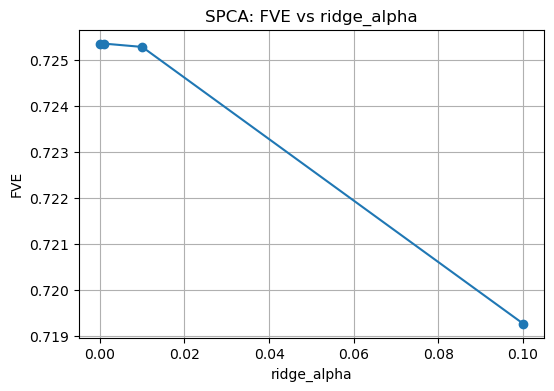

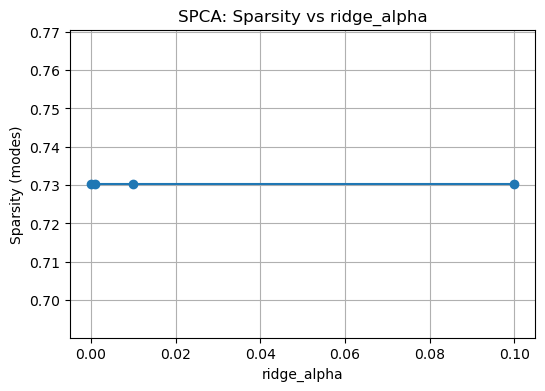

In [36]:

sweep_df = pd.DataFrame(rows).sort_values("ridge_alpha").reset_index(drop=True)
print(sweep_df.to_string(index=False))


# --- quick visuals ---
plt.figure(figsize=(6,4))
plt.plot(sweep_df["ridge_alpha"], sweep_df["FVE"], marker="o")
plt.xlabel("ridge_alpha"); plt.ylabel("FVE"); plt.title("SPCA: FVE vs ridge_alpha"); plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(sweep_df["ridge_alpha"], sweep_df["sparsity_modes"], marker="o")
plt.xlabel("ridge_alpha"); plt.ylabel("Sparsity (modes)"); plt.title("SPCA: Sparsity vs ridge_alpha"); plt.grid(True)
plt.show()

In [ ]:
# --- grid to test ---
alpha = 1.0
n_components = range(5, 101, 5)
keep_q = 0.35
use_minibatch = True

rows = []
for c in n_components:
    res = spca_pipeline(
        X_snap,
        n_components=c,
        alpha=alpha,
        keep_q=keep_q,
        use_minibatch=use_minibatch,
        compute_fve=True,
        random_state=0
    )
    rows.append({
        "alpha": alpha,
        "n_components": c,
        "keep_q": keep_q,
        "kept_features": int(res["feature_mask"].sum()),
        "total_features": X_snap.shape[1],
        "sparsity_modes": res["sparsity_modes"],
        "FVE": res["fve"],
        "time_sec": res["time_sec"]
    })
    print(f"Done n_components={c}")

 alpha  n_components  keep_q  kept_features  total_features  sparsity_modes      FVE  time_sec
   1.0             5    0.35          60068          171622        0.669678 0.605386 34.015291
   1.0            10    0.35          60068          171622        0.715126 0.707814 40.419774
   1.0            15    0.35          60068          171622        0.751338 0.746653 46.658929
   1.0            20    0.35          60068          171622        0.777466 0.772173 51.657238
   1.0            25    0.35          60068          171622        0.790919 0.789948 51.809717
   1.0            30    0.35          60068          171622        0.806730 0.804168 65.381962
   1.0            35    0.35          60068          171622        0.823541 0.816287 54.318979
   1.0            40    0.35          60068          171622        0.830701 0.826068 60.151653
   1.0            45    0.35          60068          171622        0.841837 0.834301 61.874365
   1.0            50    0.35          60068       

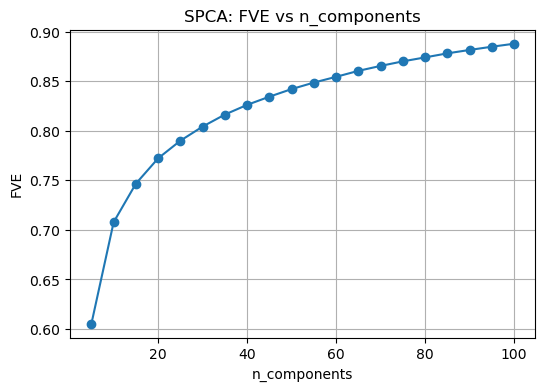

In [25]:
sweep_df = pd.DataFrame(rows).sort_values("n_components").reset_index(drop=True)
print(sweep_df.to_string(index=False))


# --- quick visuals ---
plt.figure(figsize=(6,4))
plt.plot(sweep_df["n_components"], sweep_df["FVE"], marker="o")
plt.xlabel("n_components"); plt.ylabel("FVE"); plt.title("SPCA: FVE vs n_components"); plt.grid(True)
plt.show()

In [27]:
keep_q_list = [0.2, 0.25, 0.3, 0.35, 0.4]
n_components = 30
use_minibatch = True
a = 0.05
rows = []
for q in keep_q_list:
    res = spca_pipeline(X_snap, n_components=n_components, alpha=a, keep_q=q,
                        use_minibatch=use_minibatch, compute_fve=True, random_state=0)
    rows.append({"keep_q": q, "kept_features": int(res["feature_mask"].sum()),
                 "sparsity_modes": res["sparsity_modes"], "FVE": res["fve"], "time_sec": res["time_sec"]})
pd.DataFrame(rows)


,keep_q,kept_features,sparsity_modes,FVE,time_sec
0,0.20,34325,0.803830,0.766364,62.113365
1,0.25,42906,0.754518,0.771068,65.484255
2,0.30,51487,0.706355,0.791221,73.072706
3,0.35,60068,0.658250,0.810689,94.641170
4,0.40,68649,0.610207,0.825351,95.336262


In [26]:
mask = res["feature_mask"]
Xs = StandardScaler().fit_transform(X_snap[:, mask])
p = PCA(n_components=30, svd_solver="randomized", random_state=0).fit(Xs)
# FVE in standardized space
Zk = p.transform(Xs)
R = Zk @ p.components_
fve_pca = 1 - np.linalg.norm(Xs - R, 'fro')**2 / np.linalg.norm(Xs, 'fro')**2
print("PCA FVE (same mask, k=12):", float(fve_pca))

PCA FVE (same mask, k=12): 0.8110832571983337


### SPCA computation with optimal parameters

In [39]:
res = spca_pipeline(X_snap, n_components=30, alpha=1.0, keep_q=0.35, use_minibatch=True, compute_fve=True)

In [40]:
print(f"Sparsity on modes (orig space): {res['sparsity_modes']:.3f}")
print(f"FVE: {res['fve']:.3f}  |  Time: {res['time_sec']:.1f}s  |  kept features: {res['feature_mask'].sum()} / {X_snap.shape[1]}")

SPCA_MODES = res["components"]      # shape (k, d)

Sparsity on modes (orig space): 0.807
FVE: 0.804  |  Time: 83.3s  |  kept features: 60068 / 171622


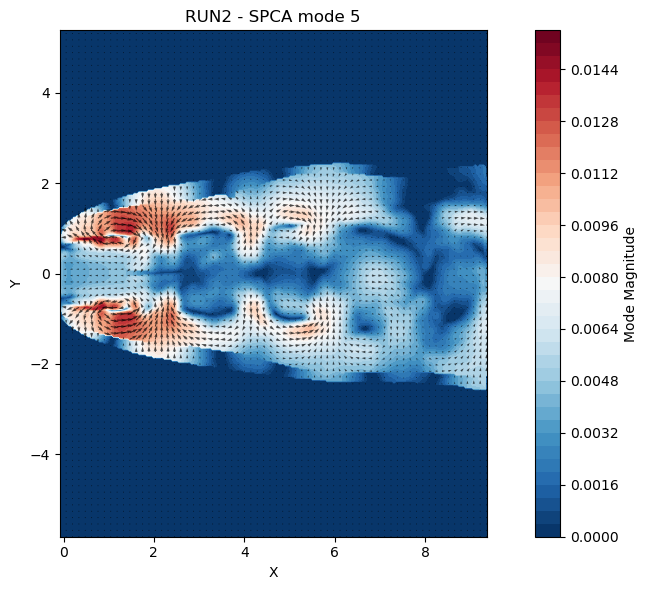

In [41]:
m = 5

plot_spod_mode(X_grid, Y_grid, SPCA_MODES[m].reshape(2, nx, ny),
               title=f"RUN2 - SPCA mode {m}",
                scale=0.6, quiver_step=4)

In [42]:
np.savez("SPCA_data/RUN2_PIV_SPCA.npz",
         components=res["components"],     # (k, d) modes in original space
         scores=res["codes"],               # (n, k) sparse coefficients
         feature_mask=res["feature_mask"], # boolean mask
         sparsity_modes=res["sparsity_modes"],
         FVE=res["fve"],
         time_sec=res["time_sec"])

In [43]:
res["codes"].shape

(2030, 30)

## t-SNE

### Scores for downstream t-SNE / clustering
In this section, I will use **scores** (temporal coefficients) as features for t-SNE and clustering.  

In [4]:
import numpy as np
data = np.load("SPCA_data/RUN2_PIV_SPCA.npz")

In [5]:
scores_spca   = data["scores"]  # (n, k)
scores_spca.shape

(2030, 30)

In [6]:
# Paper: van der Maaten & Hinton (2008), "Visualizing Data using t-SNE"

import numpy as np

def _pairwise_squared_euclidean(X):
    # Fast all-pairs distances using ||xi - xj||^2 = ||xi||^2 + ||xj||^2 - 2 * xi·xj
    sum_X = np.sum(X**2, axis=1, keepdims=True)
    D = sum_X + sum_X.T - 2 * (X @ X.T)
    np.fill_diagonal(D, 0.0)
    return np.maximum(D, 0.0)

def _hbeta(Di, beta):
    """
    Compute conditional probs P_{j|i} proportional to exp(-beta * D_ij) and entropy H(P_i).
    This is the Gaussian conditional of SNE/t-SNE (Eq. (1) for p_{j|i}).
    We return H in nats; with nats, perplexity = exp(H).
    """
    P = np.exp(-Di * beta)
    P[Di == 0] = 0.0
    sumP = np.maximum(P.sum(), 1e-12)
    Pi = P / sumP
    # H(P_i) in nats; target will be log(perplexity) accordingly.
    H = np.log(sumP) + beta * np.sum(Di * Pi)
    return H, Pi

def _binary_search_perplexity(D, perplexity, tol=1e-5, max_iter=50):
    """
    For each i, find beta_i = 1/(2 sigma_i^2) so that Perp(P_i) ~ target.
    Perplexity increases monotonically with sigma_i; binary search is the paper's procedure.
    Returns row-stochastic P_{j|i} with zeros on the diagonal (Algorithm 1, first step).
    """
    n = D.shape[0]
    P = np.zeros((n, n), dtype=np.float64)
    target_H = np.log(perplexity)  # nats, consistent with H above

    betas = np.ones(n, dtype=np.float64)
    beta_min = np.full(n, -np.inf)
    beta_max = np.full(n,  np.inf)

    for i in range(n):
        Di = D[i].copy()
        Di[i] = 0.0

        H, Pi = _hbeta(Di, betas[i])
        n_tries = 0
        while np.abs(H - target_H) > tol and n_tries < max_iter:
            if H > target_H:
                # Entropy too high -> sharpen (increase beta) to reduce entropy
                beta_min[i] = betas[i]
                betas[i] = betas[i] * 2 if np.isinf(beta_max[i]) else 0.5 * (betas[i] + beta_max[i])
            else:
                # Entropy too low -> flatten (decrease beta)
                beta_max[i] = betas[i]
                betas[i] = betas[i] / 2 if np.isinf(beta_min[i]) else 0.5 * (betas[i] + beta_min[i])
            H, Pi = _hbeta(Di, betas[i])
            n_tries += 1

        P[i, :] = Pi
    return P

def _symmetrize_normalize(P):
    """
    Form joint high-D similarities:
        p_ij = (p_{j|i} + p_{i|j}) / (2n)  (symmetric SNE joint; Eq. (6) uses these p_ij).
    Normalize so sum_{i != j} p_ij = 1; set tiny floor for numerical stability.
    (Algorithm 1: "set p_ij = (p_{j|i}+p_{i|j})/(2n)".)
    """
    n = P.shape[0]
    P = (P + P.T)
    P /= np.maximum(P.sum(), 1e-12)
    P = np.maximum(P, 1e-12)
    return P

def tsne(
    X,
    n_components=2,
    perplexity=30.0,
    n_iter=1000,
    learning_rate=200.0,
    early_exaggeration=12.0,
    exaggeration_iters=250,
    momentum=0.5,
    final_momentum=0.8,
    switch_momentum_iter=250,
    seed=42,
    init="pca",
    verbose=True
):
    """
    Implements symmetric t-SNE with Student-t low-D affinities (Eq. (4)), KL(P||Q) objective (Eq. (6)),
    and gradient (Eq. (5)), optimized with momentum as in Algorithm 1 / Section 3.4.
    """
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=np.float64)
    n, d = X.shape

    # --- Init (Algorithm 1: sample small Gaussian; we instead use tiny PCA init for stability)
    if init == "pca":
        Xc = X - X.mean(axis=0, keepdims=True)
        U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
        Y = U[:, :n_components] * S[:n_components]
        Y = (Y - Y.mean(axis=0)) / (Y.std(axis=0) + 1e-12) * 1e-4
    else:
        Y = rng.normal(0, 1e-4, size=(n, n_components))

    # --- High-D probabilities P (Algorithm 1: compute p_{j|i} with target perplexity)
    if verbose: print("[t-SNE] Computing pairwise distances...")
    D = _pairwise_squared_euclidean(X)

    if verbose: print("[t-SNE] Searching sigmas for target perplexity...")
    Pcond = _binary_search_perplexity(D, perplexity=perplexity)
    P = _symmetrize_normalize(Pcond)  # produces p_ij used in Eq. (6)

    # --- Early exaggeration (Section 3.4: multiply p_ij in early iters to form tight clusters)
    P *= early_exaggeration

    # Optimization state (Algorithm 1: gradient descent with momentum alpha(t))
    Y_inc = np.zeros_like(Y)
    gains = np.ones_like(Y)

    if verbose:
        print("[t-SNE] Optimizing embedding...")
        print(f"       n={n}, dim={d} -> {n_components}, perplexity={perplexity}, iters={n_iter}")

    for it in range(1, n_iter + 1):
        # --- Low-D affinities Q with Student-t(df=1) kernel (Eq. (4))
        # q_ij proportional to (1 + ||y_i - y_j||^2)^(-1); then normalize so sum q_ij = 1 (i != j).
        sum_Y = np.sum(Y**2, axis=1, keepdims=True)
        num = 1.0 / (1.0 + sum_Y + sum_Y.T - 2 * (Y @ Y.T))
        np.fill_diagonal(num, 0.0)
        Q = num / np.maximum(num.sum(), 1e-12)
        Q = np.maximum(Q, 1e-12)

        # --- Gradient of KL(P||Q): deltaC/delta y_i = 4 * sum_j (p_ij - q_ij) * (y_i - y_j) / (1 + ||y_i - y_j||^2) (Eq. (5))
        PQdiff = (P - Q) * num
        colsum = PQdiff.sum(axis=1, keepdims=True)
        grad = 4.0 * (Y * colsum - PQdiff @ Y)

        # Momentum schedule alpha(t) (Algorithm 1 / Section 3.4)
        m = final_momentum if it >= switch_momentum_iter else momentum

        # Adaptive learning-rate scheme (Jacobs 1988, referenced in Section 3.4)
        gains = (gains + 0.2) * ((np.sign(grad) != np.sign(Y_inc)).astype(np.float64)) + \
                (gains * 0.8) * ((np.sign(grad) == np.sign(Y_inc)).astype(np.float64))
        gains = np.clip(gains, 0.01, np.inf)

        # Update Y (Algorithm 1 update rule; KL is Eq. (6), whose value we monitor below)
        Y_inc = m * Y_inc - learning_rate * (gains * grad)
        Y += Y_inc
        Y -= Y.mean(axis=0, keepdims=True)  # keep map centered (translation invariance)

        # End early exaggeration after a fixed number of iterations (Section 3.4)
        if it == exaggeration_iters:
            P /= np.maximum(early_exaggeration, 1e-12)

        if verbose and (it % 100 == 0 or it in (1, exaggeration_iters, n_iter)):
            # KL(P||Q) = sum_{i != j} p_ij * log(p_ij / q_ij) (Eq. (6))
            kl = np.sum(P * (np.log(P + 1e-12) - np.log(Q + 1e-12)))
            print(f"  iter {it:4d}: KL={kl:.5f}")

    return Y


In [7]:
# Example with synthetic blobs
from sklearn.datasets import make_blobs

X = scores_spca  # (n, k) data matrix from SPCA
y = np.arange(X.shape[0])  # dummy labels for coloring
Y = tsne(X, n_components=2, perplexity=30, n_iter=1000, learning_rate=200, verbose=True)

[t-SNE] Computing pairwise distances...
[t-SNE] Searching sigmas for target perplexity...
[t-SNE] Optimizing embedding...
       n=2030, dim=30 -> 2, perplexity=30, iters=1000
  iter    1: KL=78.57705
  iter  100: KL=54.22015
  iter  200: KL=50.63077
  iter  250: KL=1.67156
  iter  300: KL=1.02763
  iter  400: KL=0.78027
  iter  500: KL=0.73133
  iter  600: KL=0.70987
  iter  700: KL=0.69737
  iter  800: KL=0.68899
  iter  900: KL=0.68291
  iter 1000: KL=0.67823


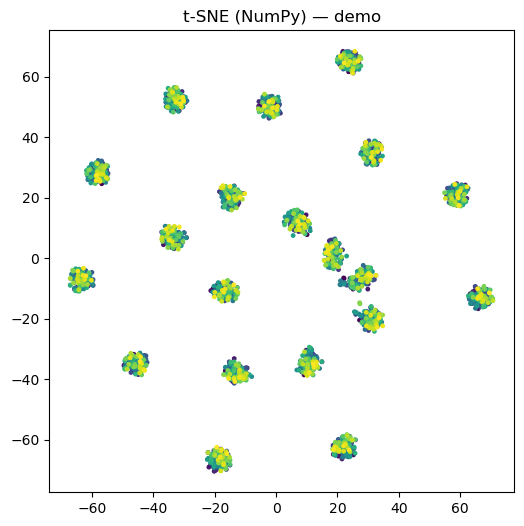

In [8]:
# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(Y[:,0], Y[:,1], s=6, c=y)
plt.title("t-SNE (NumPy) — demo")
plt.show()

The t-SNE map of the SPCA-reduced snapshots reveals tight, well-separated clusters, suggesting that the dataset contains distinct families of coherent flow states. SPCA extracted interpretable sparse modes, and t-SNE has reorganized the snapshot space into a 2D layout where these flow regimes appear as compact groups. This visualization complements the energy-based picture from SPCA/POD by emphasizing state separability and local neighborhood structure.

However, we should keep in mind that relative position of clusters in the 2D space is not globally meaningful (don’t interpret distances across far-away islands); only which points group together matters.

## Clustering

In [9]:
# === 0) Imports ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
# If you already have Y_tsne from your own impl, skip sklearn TSNE
from sklearn.manifold import TSNE  # only for quick viz if needed

In [10]:
# === 1) Inputs ===
scores = scores_spca  # <- replace

Y_tsne = Y


In [11]:
# === 2) Preprocess ===
# Standardize scores so each component contributes comparably to distances
scaler = StandardScaler()
Zscores = scaler.fit_transform(scores)

In [12]:
# === 3) Choose a distance + linkage, build hierarchy ===
# Good defaults: Euclidean + Ward
metric = "euclidean"
method = "ward"  # "ward", "average", "complete", "single"
Z = linkage(Zscores, method=method, metric=metric if method != "ward" else "euclidean")

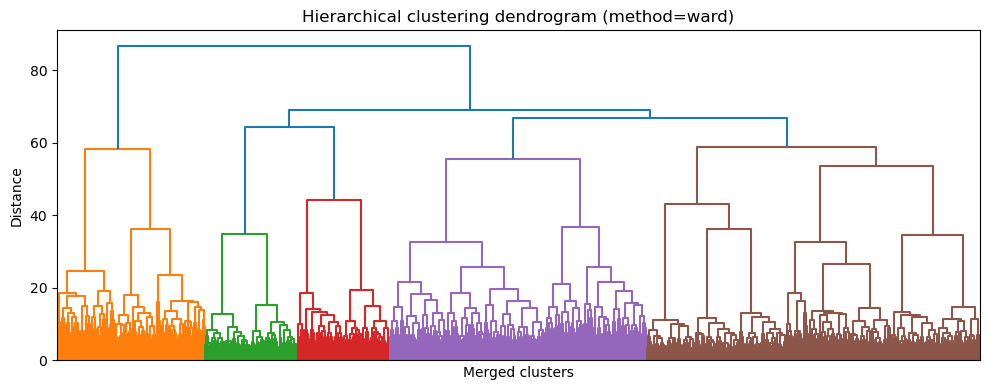

In [13]:
plt.figure(figsize=(10, 4))
dendrogram(
    Z, p=30, show_leaf_counts=True, leaf_rotation=90,
    color_threshold=None, no_labels=True
)
plt.title(f"Hierarchical clustering dendrogram (method={method})")
plt.xlabel("Merged clusters")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [14]:
# === 5) Model selection: pick the number of clusters (k) ===
candidate_k = np.arange(2, 20)

# Precompute condensed distance for efficiency with non-Euclidean metrics
pairwise = None
use_pairwise = (metric != "euclidean" or method == "single")
if use_pairwise:
    pairwise = squareform(pdist(Zscores, metric=metric))

sil_scores, db_scores, ch_scores = [], [], []
for k in candidate_k:
    labels_k = fcluster(Z, t=k, criterion="maxclust")
    if use_pairwise:
        sil = silhouette_score(pairwise, labels_k, metric="precomputed")
    else:
        sil = silhouette_score(Zscores, labels_k, metric="euclidean")
    db = davies_bouldin_score(Zscores, labels_k)
    ch = calinski_harabasz_score(Zscores, labels_k)
    sil_scores.append(sil); db_scores.append(db); ch_scores.append(ch)

# Print all results
print("k | silhouette | DB (lower=better) | CH (higher=better)")
print("-"*50)
for k, sil, db, ch in zip(candidate_k, sil_scores, db_scores, ch_scores):
    print(f"{k:2d} | {sil:9.3f} | {db:17.3f} | {ch:17.1f}")

# Best k by silhouette
best_idx = int(np.argmax(sil_scores))
k_best = int(candidate_k[best_idx])
print("\nChosen k (max silhouette): "
      f"{k_best} | silhouette={sil_scores[best_idx]:.3f}, "
      f"DB={db_scores[best_idx]:.3f}, CH={ch_scores[best_idx]:.1f}")

k | silhouette | DB (lower=better) | CH (higher=better)
--------------------------------------------------
 2 |     0.149 |             2.966 |             133.5
 3 |     0.053 |             3.276 |             113.8
 4 |     0.057 |             3.320 |             107.9
 5 |     0.050 |             2.993 |             105.0
 6 |     0.052 |             2.833 |             101.3
 7 |     0.063 |             2.718 |              99.7
 8 |     0.077 |             2.619 |              98.1
 9 |     0.091 |             2.548 |              96.9
10 |     0.099 |             2.447 |              93.2
11 |     0.084 |             2.387 |              90.1
12 |     0.089 |             2.443 |              86.2
13 |     0.092 |             2.494 |              83.0
14 |     0.092 |             2.424 |              80.4
15 |     0.093 |             2.370 |              78.0
16 |     0.096 |             2.342 |              75.9
17 |     0.100 |             2.315 |              73.9
18 |     0.10

In [15]:
# === 6) Final labels with chosen k ===
labels = fcluster(Z, t=k_best, criterion="maxclust")
np.unique(labels, return_counts=True)


(array([1, 2], dtype=int32), array([ 326, 1704]))

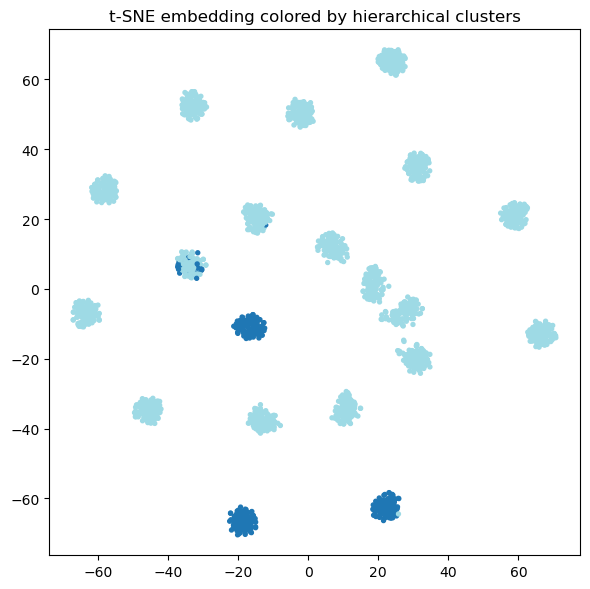

In [16]:
# === 7) Visualize clusters on t-SNE map ===
plt.figure(figsize=(6, 6))
plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], s=8, c=labels, cmap="tab20")
plt.title("t-SNE embedding colored by hierarchical clusters")
plt.axis("equal"); plt.tight_layout(); plt.show()

In [17]:
# === 6) Final labels with chosen k ===
# Trying with another k (obtained by taking a look at the dendogram)
labels = fcluster(Z, t=4, criterion="maxclust")
np.unique(labels, return_counts=True)

(array([1, 2, 3, 4], dtype=int32), array([326, 406, 566, 732]))

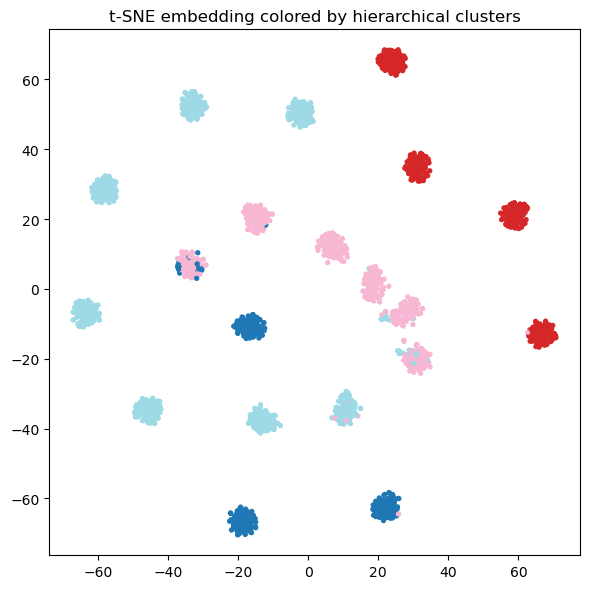

In [18]:
# === 7) Visualize clusters on t-SNE map ===
plt.figure(figsize=(6, 6))
plt.scatter(Y_tsne[:, 0], Y_tsne[:, 1], s=8, c=labels, cmap="tab20")
plt.title("t-SNE embedding colored by hierarchical clusters")
plt.axis("equal"); plt.tight_layout(); plt.show()

In [23]:
np.savez("clustering_data/RUN2_PIV_labels.npz", labels=labels)

## Centroid Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from data_utils import plot_velocity_field
data = np.load("compressed_data/RUN2_PIV_compressed.npz")
labels_data = np.load("clustering_data/RUN2_PIV_labels.npz")

In [2]:
def compute_cluster_centroids(u, v, labels):
    """
    Compute centroid (mean) velocity fields per cluster.

    Parameters
    ----------
    u, v : arrays of shape (n_snapshots, nx, ny)
        Velocity components per snapshot.
    labels : array of shape (n_snapshots,)
        Cluster IDs (e.g., from fcluster).

    Returns
    -------
    clusters : (n_clusters,) array of cluster IDs (sorted unique labels)
    uc : (n_clusters, nx, ny) array with centroid u per cluster
    vc : (n_clusters, nx, ny) array with centroid v per cluster
    sizes : (n_clusters,) array with number of snapshots per cluster
    """
    u = np.asarray(u); v = np.asarray(v); labels = np.asarray(labels)
    clusters = np.unique(labels)
    nx, ny = u.shape[1], u.shape[2]

    uc = np.empty((len(clusters), nx, ny), dtype=float)
    vc = np.empty((len(clusters), nx, ny), dtype=float)
    sizes = np.empty(len(clusters), dtype=int)

    for i, c in enumerate(clusters):
        mask = (labels == c)
        sizes[i] = int(mask.sum())
        # vector mean across snapshots belonging to cluster c
        uc[i] = u[mask].mean(axis=0)
        vc[i] = v[mask].mean(axis=0)

    return clusters, uc, vc, sizes

In [3]:
clusters, uc, vc, sizes = compute_cluster_centroids(data["u"], data["v"], labels_data["labels"])

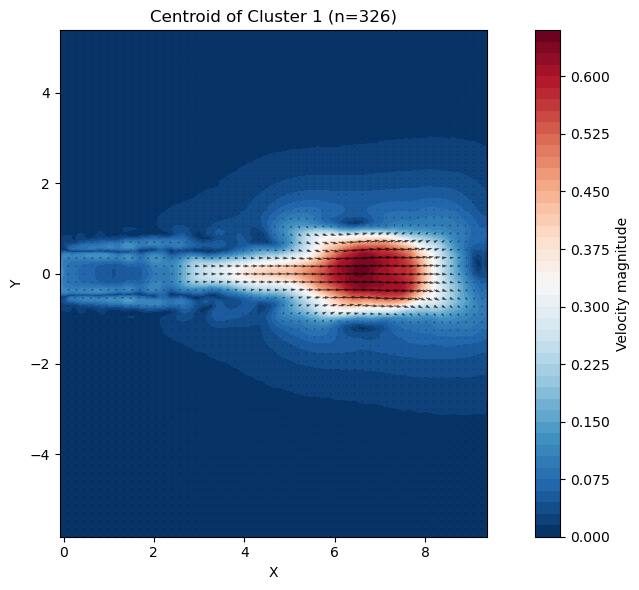

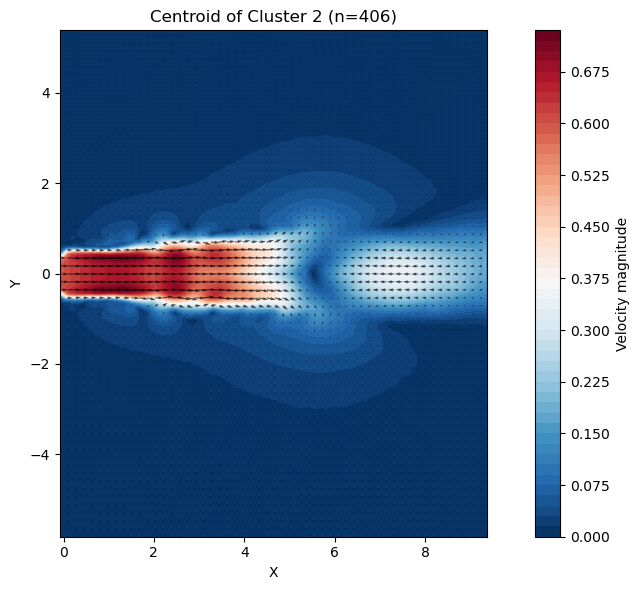

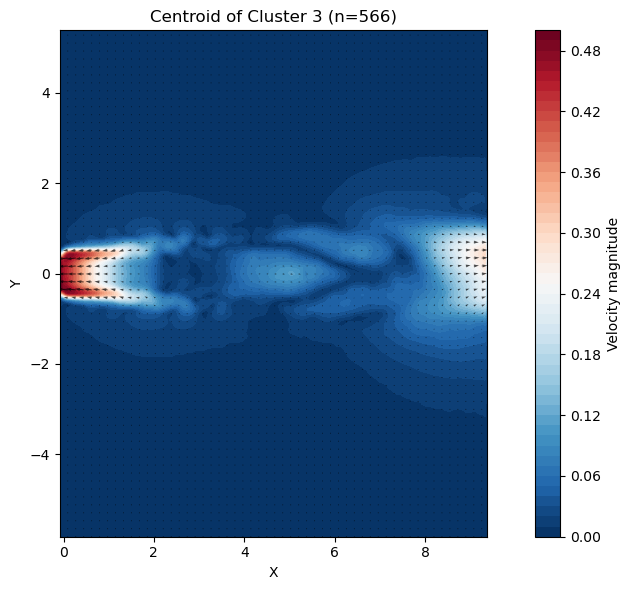

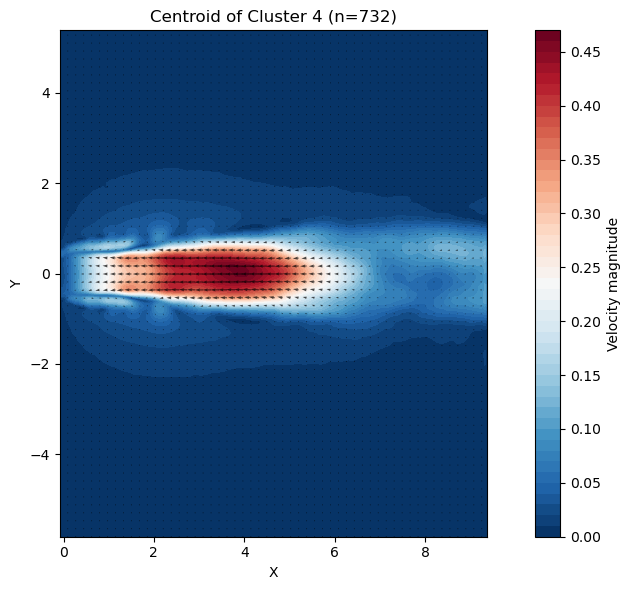

In [24]:
quiver_step = 5   # subsample grid for quiver arrows
scale = 20        # tweak for arrow scaling

for i, c in enumerate(clusters):
    plot_velocity_field(data["X"], data["Y"], uc[i], vc[i],
                        title=f"Centroid of Cluster {int(c)} (n={int(sizes[i])})",
                        scale=scale, quiver_step=quiver_step)

The centroid plots for each cluster look pretty different from each other, which hints that the algorithm has grouped together snapshots showing distinct flow patterns. In other words, the clusters might correspond to different fluid structures in the jet. That said, I’m not a fluid mechanics expert, so I can’t say exactly which structures they are (like specific vortex types or shear-layer features). What I can conclude is that the clustering step is doing its job of separating the data into meaningful groups, and someone with more background in jet flows would be able to give a clearer physical interpretation of what each cluster represents.

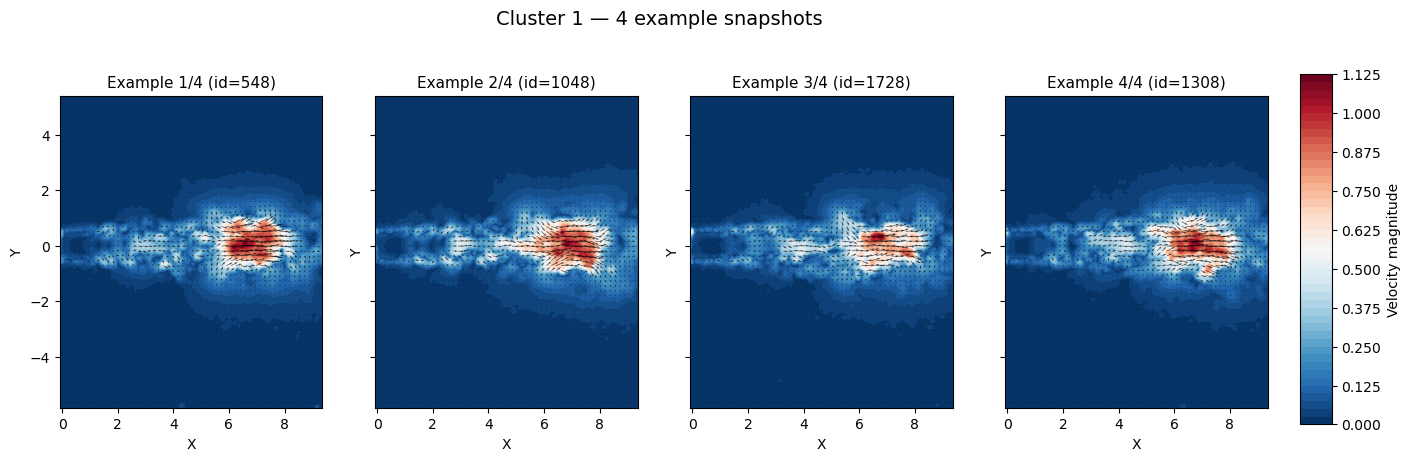

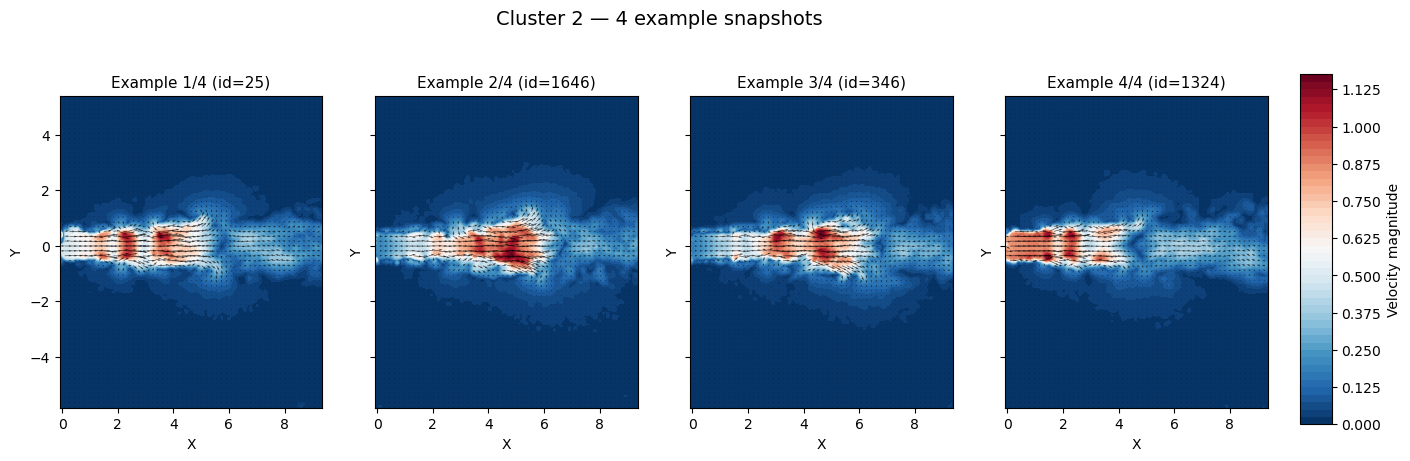

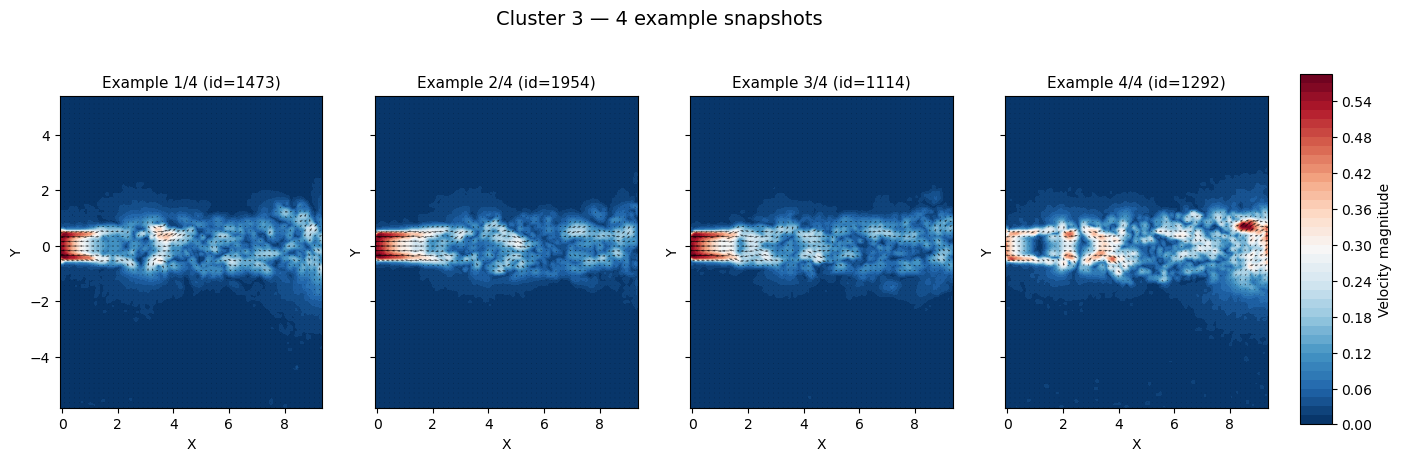

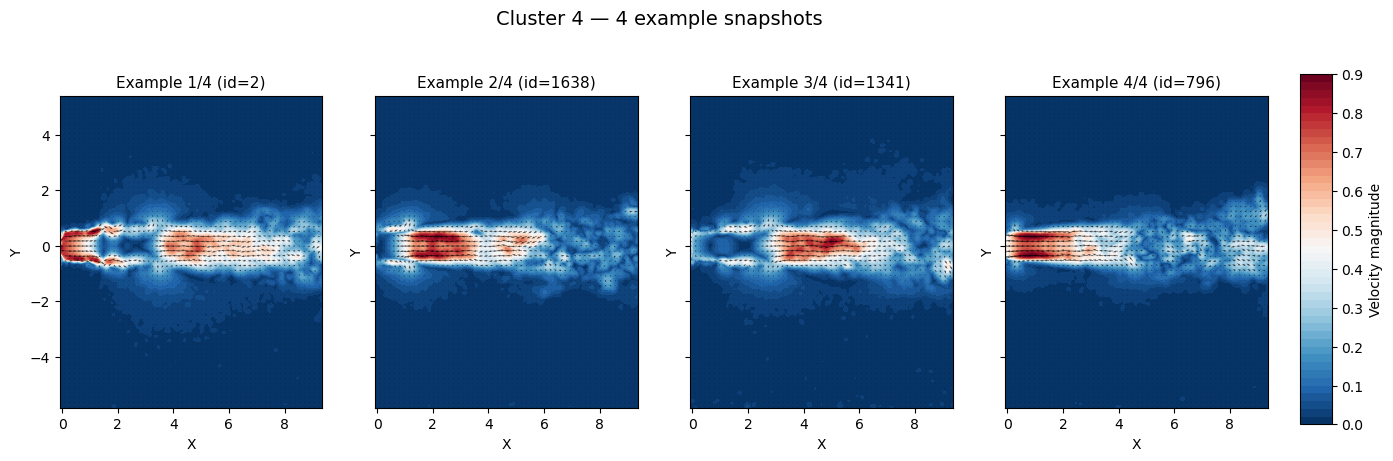

In [32]:
n_examples = 4
rng = np.random.default_rng(0)

quiver_step = 5
scale = 20

for i, c in enumerate(clusters):
    idx = np.flatnonzero(labels_data["labels"] == c)
    if idx.size == 0:
        continue
    take = min(n_examples, idx.size)
    ex_ids = rng.choice(idx, size=take, replace=False) if rng is not None else idx[:take]

    # make figure with subplots
    fig, axes = plt.subplots(1, take, figsize=(4*take, 5), sharex=True, sharey=True)
    if take == 1:
        axes = [axes]

    cont = None
    for j, (ax, ex) in enumerate(zip(axes, ex_ids), start=1):
        u_ex = data["u"][ex]
        v_ex = data["v"][ex]
        mag = np.hypot(u_ex, v_ex)

        cont = ax.contourf(data["X"], data["Y"], mag, cmap="RdBu_r", levels=50)
        ax.quiver(
            data["X"][::quiver_step, ::quiver_step],
            data["Y"][::quiver_step, ::quiver_step],
            u_ex[::quiver_step, ::quiver_step],
            v_ex[::quiver_step, ::quiver_step],
            scale=scale, color="k", alpha=0.7
        )
        ax.set_title(f"Example {j}/{take} (id={int(ex)})", fontsize=11)
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_aspect("equal")

    # adjust layout to leave space on the right
    plt.subplots_adjust(right=0.88, wspace=0.2)

    # add a dedicated colorbar axis (left, bottom, width, height in figure coords)
    cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(cont, cax=cbar_ax)
    cbar.set_label("Velocity magnitude")

    fig.suptitle(f"Cluster {int(c)} — {take} example snapshots", fontsize=14, y=0.98)
    plt.show()

# Multiple t-SNE Runs for Stability Analysis and Centroid Visualization

Running t-SNE trial 1/10...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2030 samples in 0.005s...
[t-SNE] Computed neighbors for 2030 samples in 11.941s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2030
[t-SNE] Computed conditional probabilities for sample 2000 / 2030
[t-SNE] Computed conditional probabilities for sample 2030 / 2030
[t-SNE] Mean sigma: 39.174825
[t-SNE] KL divergence after 250 iterations with early exaggeration: 49.734047
[t-SNE] KL divergence after 1000 iterations: 0.698824
Trial 1 KL divergence: 0.6988, time: 18.01s
Running t-SNE trial 2/10...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2030 samples in 0.001s...
[t-SNE] Computed neighbors for 2030 samples in 0.089s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2030
[t-SNE] Computed conditional probabilities for sample 2000 / 2030
[t-SNE] Computed conditional probabilities for sample 2030 / 2030
[t-SNE] Mean sigma: 39.174825
[t-SNE] KL divergence after 2

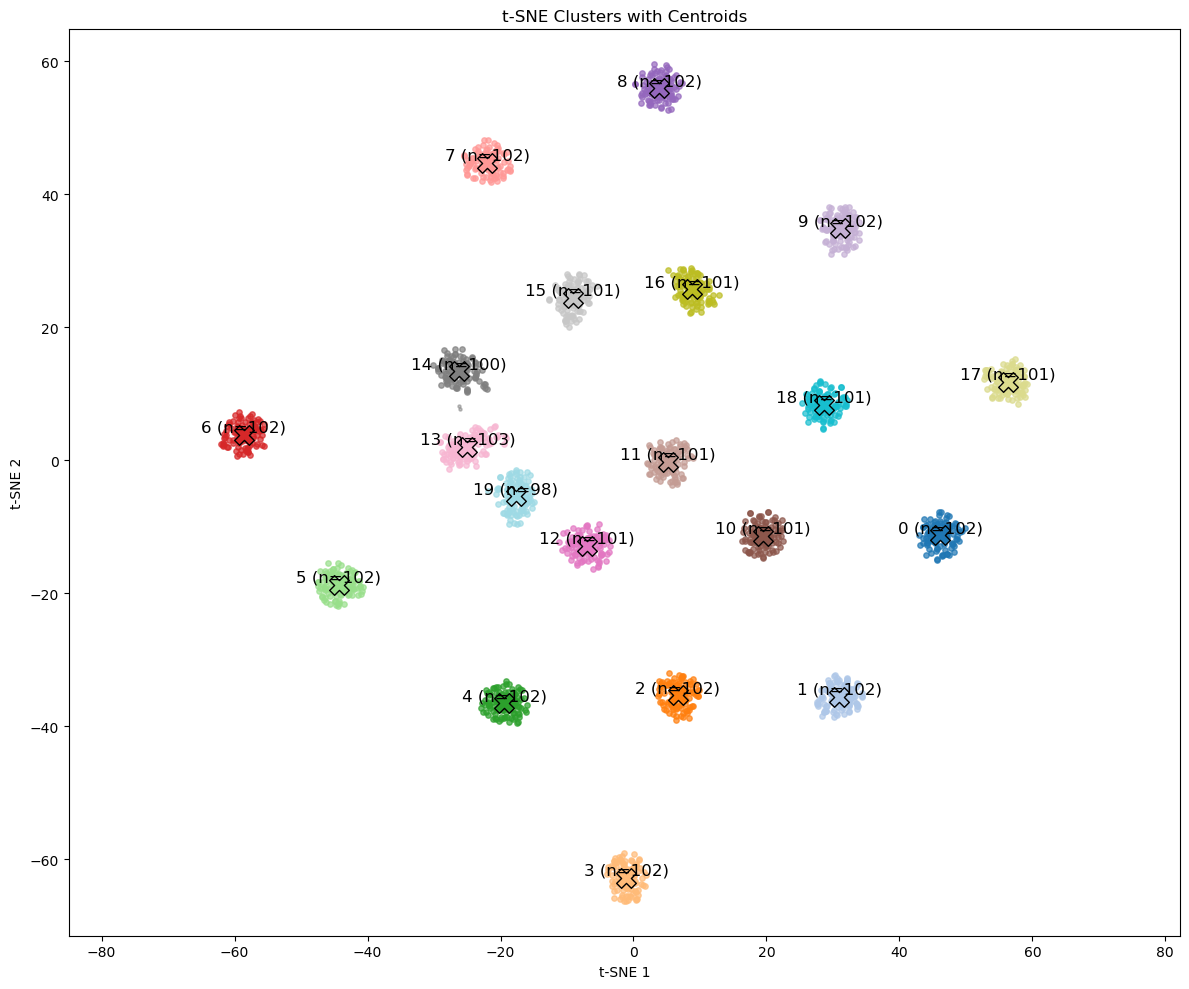

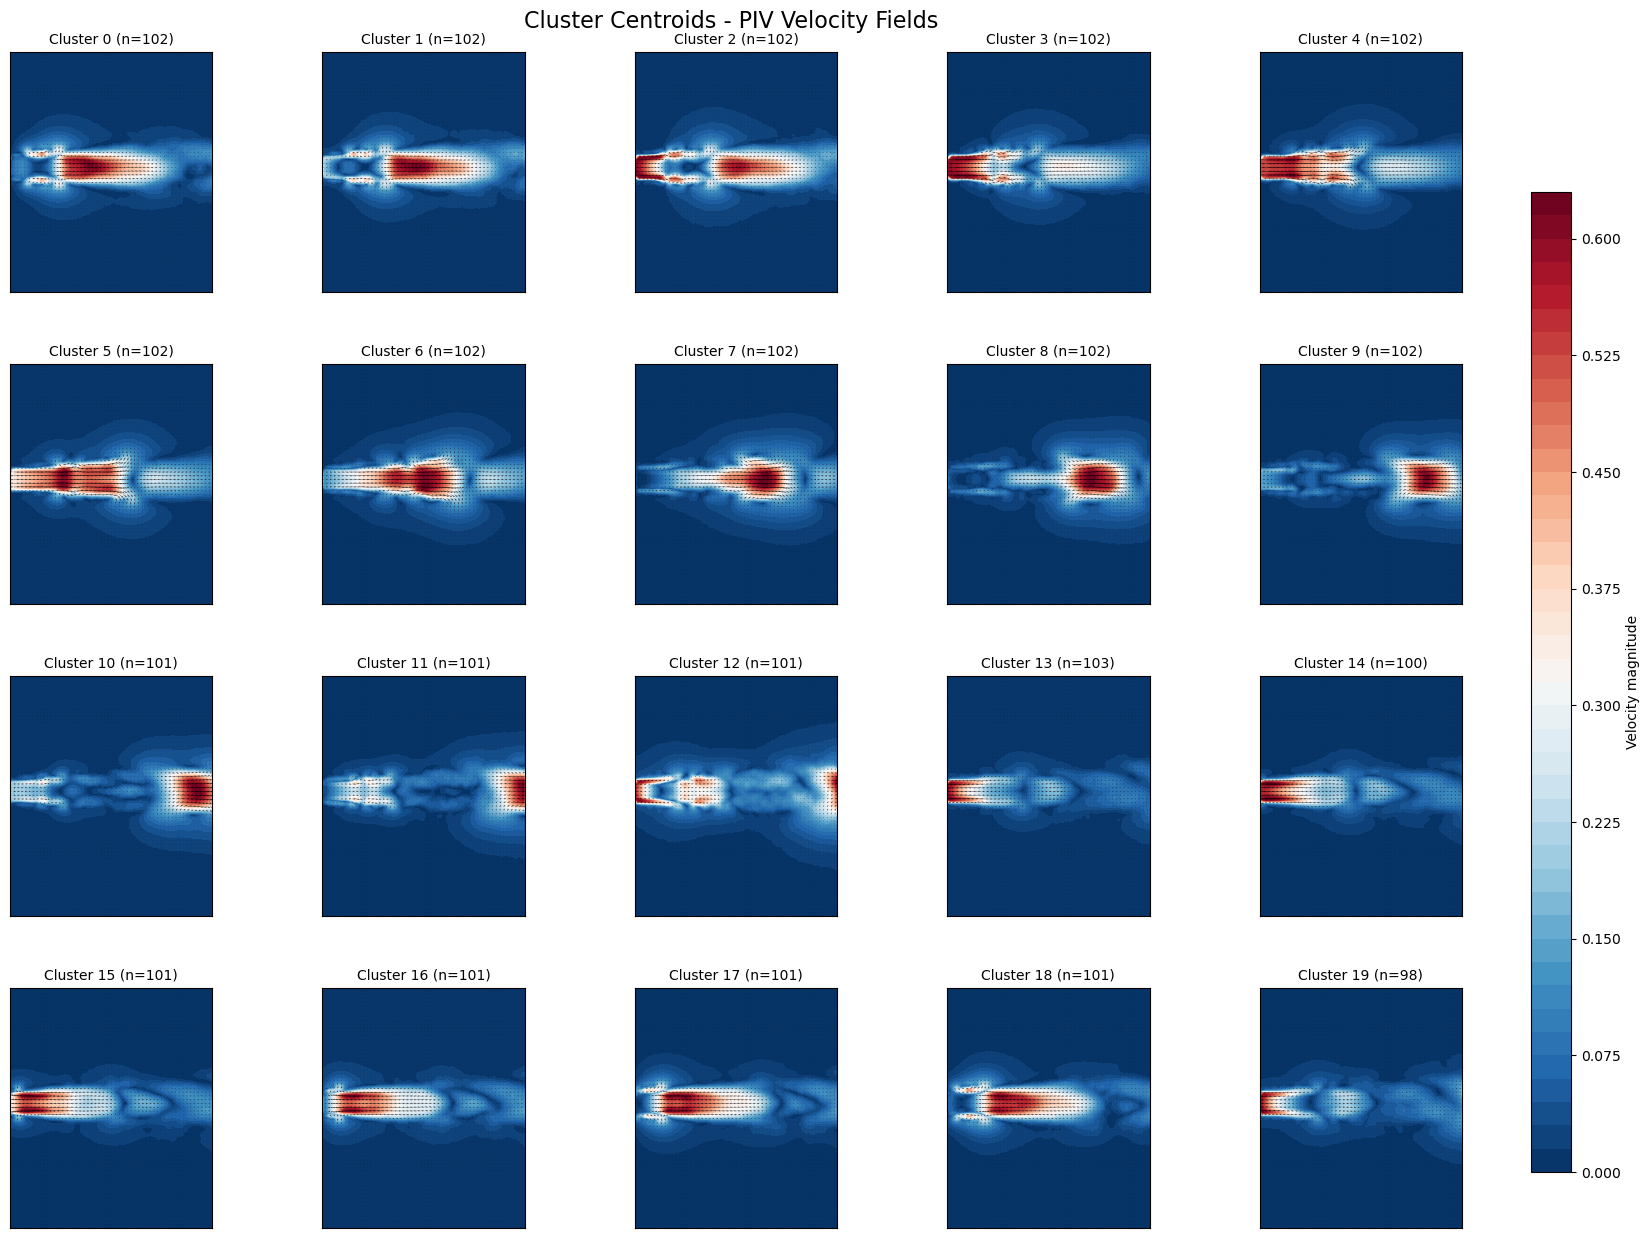


Analyzing run 1/10...
Found 20 clusters in t-SNE embedding

Analyzing run 2/10...
Found 20 clusters in t-SNE embedding

Analyzing run 3/10...
Found 20 clusters in t-SNE embedding

Analyzing run 4/10...
Found 20 clusters in t-SNE embedding

Analyzing run 5/10...
Found 20 clusters in t-SNE embedding

Analyzing run 6/10...
Found 20 clusters in t-SNE embedding

Analyzing run 7/10...
Found 20 clusters in t-SNE embedding

Analyzing run 8/10...
Found 20 clusters in t-SNE embedding

Analyzing run 9/10...
Found 20 clusters in t-SNE embedding

Analyzing run 10/10...
Found 20 clusters in t-SNE embedding

Number of clusters found in each run: [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
Mean stability score across runs: 1.0000 ± 0.0000

Final Stability Report:
------------------------
Number of t-SNE runs analyzed: 10
Clusters found in each run: [20, 20, 20, 20, 20, 20, 20, 20, 20, 20]
Average stability score: 1.0000 ± 0.0000
(Stability score is the average correlation between best-matching centroids

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from time import time
import matplotlib.gridspec as gridspec
from data_utils import plot_velocity_field
import os
from datetime import datetime

def run_multiple_tsne(X, n_runs=10, perplexity=30, learning_rate=200, max_iter=1000, random_state_start=0):
    """Run t-SNE multiple times and return the best run (lowest KL divergence)"""
    all_embeddings = []
    all_kls = []
    
    for i in range(n_runs):
        print(f"Running t-SNE trial {i+1}/{n_runs}...")
        t0 = time()
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            learning_rate=learning_rate,
            max_iter=max_iter,
            random_state=random_state_start + i,
            verbose=1
        )
        Y = tsne.fit_transform(X)
        
        all_embeddings.append(Y)
        all_kls.append(tsne.kl_divergence_)
        print(f"Trial {i+1} KL divergence: {tsne.kl_divergence_:.4f}, time: {time()-t0:.2f}s")
    
    # Find best embedding (lowest KL divergence)
    best_idx = np.argmin(all_kls)
    best_embedding = all_embeddings[best_idx]
    best_kl = all_kls[best_idx]
    
    print(f"\nBest run: {best_idx+1} with KL divergence: {best_kl:.4f}")
    
    return best_embedding, best_kl, all_embeddings, all_kls

def compute_cluster_centroids(u, v, labels):
    """
    Compute centroid (mean) velocity fields per cluster directly from original u,v data.
    """
    u = np.asarray(u)
    v = np.asarray(v)
    labels = np.asarray(labels)
    clusters = sorted(set(labels))
    if -1 in clusters:  # Remove noise label
        clusters.remove(-1)
    
    nx, ny = u.shape[1], u.shape[2]

    uc = np.empty((len(clusters), nx, ny), dtype=float)
    vc = np.empty((len(clusters), nx, ny), dtype=float)
    sizes = np.empty(len(clusters), dtype=int)

    for i, c in enumerate(clusters):
        mask = (labels == c)
        sizes[i] = int(mask.sum())
        # vector mean across snapshots belonging to cluster c
        uc[i] = u[mask].mean(axis=0)
        vc[i] = v[mask].mean(axis=0)

    return clusters, uc, vc, sizes

def analyze_tsne_clusters(embedding, scores_spca, u, v, eps=2.0, min_samples=10):
    """
    Extract clusters from t-SNE embedding and compute centroids in original PIV space
    """
    # Apply DBSCAN to find clusters
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(embedding)
    labels = db.labels_
    
    # Number of clusters (excluding noise points labeled as -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"Found {n_clusters} clusters in t-SNE embedding")
    
    # Compute centroids in t-SNE space (just for visualization)
    unique_labels = sorted(set(labels))
    if -1 in unique_labels:  # Remove noise label
        unique_labels.remove(-1)
    
    centroids_tsne = []
    for label in unique_labels:
        mask = (labels == label)
        cluster_pts_tsne = embedding[mask]
        centroid_tsne = np.mean(cluster_pts_tsne, axis=0)
        centroids_tsne.append(centroid_tsne)
    
    centroids_tsne = np.array(centroids_tsne)
    
    # Compute centroids in original PIV space (u,v components)
    clusters, uc, vc, sizes = compute_cluster_centroids(u, v, labels)
    
    return clusters, centroids_tsne, uc, vc, sizes, labels

def plot_centroids_grid(X_grid, Y_grid, uc, vc, cluster_sizes, ncols=5):
    """
    Plot all centroids in a grid layout
    """
    n_centroids = len(uc)
    nrows = int(np.ceil(n_centroids / ncols))
    
    # Create figure with appropriate size
    fig = plt.figure(figsize=(ncols * 4, nrows * 3.5))
    
    # Create grid of subplots
    axes = []
    for i in range(n_centroids):
        row = i // ncols
        col = i % ncols
        # Leave space at right for colorbar by adjusting the gridspec
        ax = plt.subplot2grid((nrows, ncols), (row, col))
        axes.append(ax)
    
    # Plot each centroid
    contours = []
    for i in range(n_centroids):
        ax = axes[i]
        
        # Calculate velocity magnitude
        velocity_mag = np.hypot(uc[i], vc[i])
        
        # Plot contour with RdBu_r colormap
        cont = ax.contourf(X_grid, Y_grid, velocity_mag, 
                          levels=50, cmap='RdBu_r')
        contours.append(cont)
        
        # Plot quiver
        quiver_step = 5
        ax.quiver(
            X_grid[::quiver_step, ::quiver_step],
            Y_grid[::quiver_step, ::quiver_step],
            uc[i][::quiver_step, ::quiver_step],
            vc[i][::quiver_step, ::quiver_step],
            scale=20, color='k', alpha=0.7
        )
        
        ax.set_title(f"Cluster {i} (n={cluster_sizes[i]})", fontsize=10)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
    

    plt.suptitle('Cluster Centroids - PIV Velocity Fields', fontsize=16, y=0.98)
    plt.subplots_adjust(right=0.88, wspace=0.2, hspace=0.3, top=0.95)
    
    cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(contours[0], cax=cbar_ax)
    cbar.set_label('Velocity magnitude')
    
    plt.show()
    return fig

def analyze_stability(all_embeddings, u, v, eps=2.0, min_samples=10):
    """Analyze stability of clusters across multiple t-SNE runs"""
    n_runs = len(all_embeddings)
    all_centroids_u = []
    all_centroids_v = []
    all_n_clusters = []
    
    # Process each run
    for i, embedding in enumerate(all_embeddings):
        print(f"\nAnalyzing run {i+1}/{n_runs}...")
        # Extract clusters and compute centroids
        clusters, _, uc, vc, _, _ = analyze_tsne_clusters(
            embedding, scores_spca, u, v, eps=eps, min_samples=min_samples)
        
        all_centroids_u.append(uc)
        all_centroids_v.append(vc)
        all_n_clusters.append(len(clusters))
    
    print(f"\nNumber of clusters found in each run: {all_n_clusters}")
    
    # Compute similarity between centroids across runs
    if len(set(all_n_clusters)) > 1:
        print("Warning: Different runs produced different numbers of clusters")
        return None, None, all_centroids_u, all_centroids_v, all_n_clusters
    
    # Compare centroids across runs
    avg_similarities = []
    for i in range(n_runs-1):
        for j in range(i+1, n_runs):
            similarities = []
            for c_idx in range(all_n_clusters[i]):
                # Find best match in the other run
                best_sim = -float('inf')
                for c_idx2 in range(all_n_clusters[j]):
                    # Compute correlation between velocity fields
                    u_corr = np.corrcoef(all_centroids_u[i][c_idx].flatten(), 
                                        all_centroids_u[j][c_idx2].flatten())[0,1]
                    v_corr = np.corrcoef(all_centroids_v[i][c_idx].flatten(), 
                                        all_centroids_v[j][c_idx2].flatten())[0,1]
                    sim = (u_corr + v_corr) / 2
                    best_sim = max(best_sim, sim)
                similarities.append(best_sim)
            avg_similarities.append(np.mean(similarities))
    
    mean_stability = np.mean(avg_similarities)
    std_stability = np.std(avg_similarities)
    
    print(f"Mean stability score across runs: {mean_stability:.4f} ± {std_stability:.4f}")
    
    return mean_stability, std_stability, all_centroids_u, all_centroids_v, all_n_clusters

# Load the data
piv_data = np.load("compressed_data/RUN2_PIV_compressed.npz")
spca_data = np.load("SPCA_data/RUN2_PIV_SPCA.npz")

# Extract PIV components and SPCA scores
u = piv_data["u"]
v = piv_data["v"]
X_grid = piv_data["X"]
Y_grid = piv_data["Y"]
scores_spca = spca_data["scores"]

# Run multiple t-SNE trials and get the best one
best_Y_tsne, best_kl, all_embeddings, all_kls = run_multiple_tsne(
    scores_spca, 
    n_runs=10,  # Using all 10 runs for stability analysis
    perplexity=30, 
    learning_rate=200,
    max_iter=1000
)

# Extract clusters and compute centroids directly in PIV space
clusters, centroids_tsne, uc, vc, cluster_sizes, labels = analyze_tsne_clusters(
    best_Y_tsne, scores_spca, u, v, eps=2.0, min_samples=10)

# Plot t-SNE with clusters
plt.figure(figsize=(12, 10))
colors = plt.cm.tab20(np.linspace(0, 1, len(clusters)))

# Plot points with cluster colors
for i, cluster_id in enumerate(clusters):
    mask = labels == cluster_id
    plt.scatter(best_Y_tsne[mask, 0], best_Y_tsne[mask, 1], 
              s=15, c=[colors[i]], alpha=0.7)

# Plot noise points if any
if -1 in np.unique(labels):
    plt.scatter(best_Y_tsne[labels == -1, 0], best_Y_tsne[labels == -1, 1], 
              s=5, c='gray', alpha=0.5, label='Noise')

# Plot centroids
for i, centroid in enumerate(centroids_tsne):
    plt.scatter(centroid[0], centroid[1], s=200, marker='X', edgecolors='k', 
               c=[colors[i]])
    plt.annotate(f"{i} (n={cluster_sizes[i]})", 
                (centroid[0], centroid[1]),
                fontsize=12, ha='center', va='bottom')

plt.title('t-SNE Clusters with Centroids')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Plot all centroids in a grid layout
plot_centroids_grid(X_grid, Y_grid, uc, vc, cluster_sizes, ncols=5)

# Analyze stability using ALL runs
stability, std_stability, all_u_centroids, all_v_centroids, all_n_clusters = analyze_stability(
    all_embeddings, u, v, eps=2.0, min_samples=10)

# Print final stability report
print(f"\nFinal Stability Report:")
print(f"------------------------")
print(f"Number of t-SNE runs analyzed: {len(all_embeddings)}")
print(f"Clusters found in each run: {all_n_clusters}")
print(f"Average stability score: {stability:.4f} ± {std_stability:.4f}")
print(f"(Stability score is the average correlation between best-matching centroids across runs)")
print(f"(Higher values indicate more consistent clusters across different t-SNE initializations)")

Previously saved cluster labels loaded successfully.


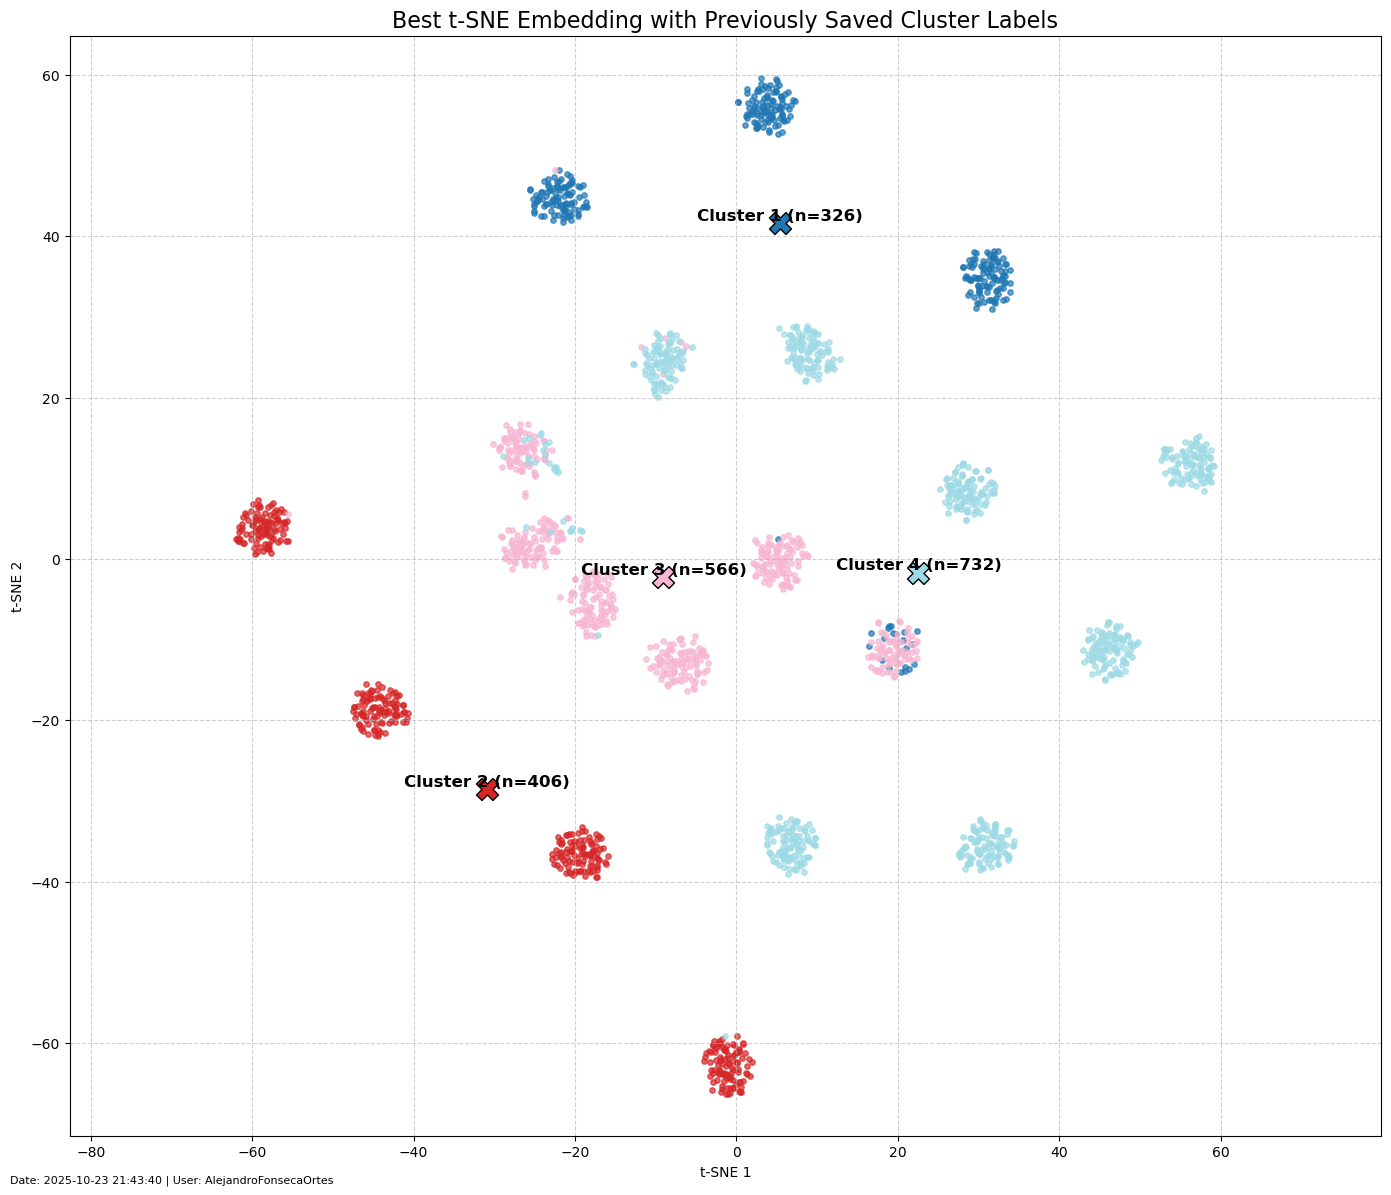

In [2]:
clustering_data = np.load("clustering_data/RUN2_PIV_labels.npz")
loaded_labels = clustering_data["labels"]
print("Previously saved cluster labels loaded successfully.")

# 2. Compute centroids for the loaded labels in the new t-SNE space
unique_loaded_labels = sorted(set(loaded_labels))
centroids_in_new_space = []
cluster_sizes_loaded = []

for label in unique_loaded_labels:
    mask = (loaded_labels == label)
    cluster_points = best_Y_tsne[mask]
    centroid = np.mean(cluster_points, axis=0)
    centroids_in_new_space.append(centroid)
    cluster_sizes_loaded.append(np.sum(mask))

centroids_in_new_space = np.array(centroids_in_new_space)

# 3. Plot the new t-SNE embedding colored by the loaded labels
plt.figure(figsize=(14, 12))
colors_loaded = plt.cm.tab20(np.linspace(0, 1, len(unique_loaded_labels)))

for i, label in enumerate(unique_loaded_labels):
    mask = (loaded_labels == label)
    plt.scatter(best_Y_tsne[mask, 0], best_Y_tsne[mask, 1], 
                s=15, c=[colors_loaded[i]], alpha=0.7)

# Plot the centroids on the new embedding
for i, centroid in enumerate(centroids_in_new_space):
    plt.scatter(centroid[0], centroid[1], s=250, marker='X', edgecolors='k', 
                c=[colors_loaded[i]])
    plt.annotate(f"Cluster {unique_loaded_labels[i]} (n={cluster_sizes_loaded[i]})", 
                (centroid[0], centroid[1]),
                fontsize=12, ha='center', va='bottom', weight='bold')

plt.title('Best t-SNE Embedding with Previously Saved Cluster Labels', fontsize=16)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.6)

# Add timestamp and user info
plt.figtext(0.01, 0.01, "Date: 2025-10-23 21:43:40 | User: AlejandroFonsecaOrtes", fontsize=8)

plt.tight_layout()
plt.show()